In [1]:
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix
from sklearn.model_selection import train_test_split
import tarfile
import requests
from pathlib import Path
from tqdm import tqdm

In [2]:
LASTFM_DIR = Path("lastfm")
ML_DIR = Path("ml-100k")

MIN_USER_INTERACTIONS = 10
MIN_ITEM_INTERACTIONS = 10

MIN_USER_INTERACTIONS_ML = 5
MIN_ITEM_INTERACTIONS_ML = 5

TEST_SIZE = 0.2
RANDOM_STATE = 42


In [3]:

def load_lastfm():
    if not LASTFM_DIR.exists():
        raise FileNotFoundError(f"Extracted directory not found: {LASTFM_DIR}")
    
    events_files = list(LASTFM_DIR.glob("userid-timestamp*.tsv"))
    
    if not events_files:
        raise FileNotFoundError(f"No events TSV file found in {LASTFM_DIR}")
    
    events_file = events_files[0]

    events_df = pd.read_csv(
        events_file,
        sep='\t',
        header=None,
        names=['user_id', 'timestamp', 'artist_id', 'artist', 'track_id', 'track'],
        engine='python',
        on_bad_lines='skip',
        quoting=3
    )
    
    print(f"Loaded {len(events_df):,} listening events")
    print(f"Users: {events_df['user_id'].nunique():,}")
    print(f"Tracks: {events_df['track_id'].nunique():,}")
    print(f"Artists: {events_df['artist'].nunique():,}")
    
    profiles_file = LASTFM_DIR / "userid-profile.tsv"
    
    if profiles_file.exists():
        profiles_df = pd.read_csv(
            profiles_file,
            sep='\t',
            header=None,
            names=['user_id', 'gender', 'age', 'country', 'signup_date'],
            engine='python',
            on_bad_lines='skip'
        )
        print(f"Loaded {len(profiles_df):,} user profiles")
    else:
        print("No user profiles file found")
        profiles_df = pd.DataFrame()
    
    return events_df, profiles_df

events_df, profiles_df = load_lastfm()

print("\nSample Events")
print(events_df.head())

if not profiles_df.empty:
    print("\nSample Profiles")
    print(profiles_df.head())

Loaded 19,150,868 listening events
Users: 992
Tracks: 961,416
Artists: 174,091
Loaded 993 user profiles

Sample Events
       user_id             timestamp                             artist_id  \
0  user_000001  2009-05-04T23:08:57Z  f1b1cf71-bd35-4e99-8624-24a6e15f133a   
1  user_000001  2009-05-04T13:54:10Z  a7f7df4a-77d8-4f12-8acd-5c60c93f4de8   
2  user_000001  2009-05-04T13:52:04Z  a7f7df4a-77d8-4f12-8acd-5c60c93f4de8   
3  user_000001  2009-05-04T13:42:52Z  a7f7df4a-77d8-4f12-8acd-5c60c93f4de8   
4  user_000001  2009-05-04T13:42:11Z  a7f7df4a-77d8-4f12-8acd-5c60c93f4de8   

      artist track_id                                       track  
0  Deep Dish      NaN  Fuck Me Im Famous (Pacha Ibiza)-09-28-2007  
1       坂本龍一      NaN           Composition 0919 (Live_2009_4_15)  
2       坂本龍一      NaN                        Mc2 (Live_2009_4_15)  
3       坂本龍一      NaN                     Hibari (Live_2009_4_15)  
4       坂本龍一      NaN                        Mc1 (Live_2009_4_15)  

Sam

In [4]:
print(f"\nMissing values:")
print(f"user_id: {events_df['user_id'].isna().sum():,}")
print(f"artist_id: {events_df['artist_id'].isna().sum():,}")
print(f"track_id: {events_df['track_id'].isna().sum():,} ({events_df['track_id'].isna().sum()/len(events_df)*100:.1f}%)")
print(f"artist: {events_df['artist'].isna().sum():,}")
print(f"track: {events_df['track'].isna().sum():,}")


Missing values:
user_id: 0
artist_id: 602,166
track_id: 2,168,588 (11.3%)
artist: 0
track: 11


In [5]:
def load_movielens():
    data_dir = ML_DIR / "ml-100k"
    if not data_dir.exists():
        data_dir = ML_DIR
    
    ratings_file = data_dir / "u.data"
    ratings_df = pd.read_csv(
        ratings_file,
        sep='\t',
        header=None,
        names=['user_id', 'item_id', 'rating', 'timestamp']
    )
    print(f"Loaded {len(ratings_df):,} ratings")
    print(f"Users: {ratings_df['user_id'].nunique():,}")
    print(f"Movies: {ratings_df['item_id'].nunique():,}")
    print(f"Rating range: {ratings_df['rating'].min()}-{ratings_df['rating'].max()}")

    user_file = data_dir / "u.user"
    user_df = pd.read_csv(
        user_file,
        sep='|',
        header=None,
        names=['user_id', 'age', 'gender', 'occupation', 'zip_code'],
        encoding='latin-1'
    )
    print(f"Loaded {len(user_df):,} user profiles")
    
    genre_names = [
        'unknown', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy',
        'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror',
        'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western'
    ]
    
    movie_file = data_dir / "u.item"
    movie_df = pd.read_csv(
        movie_file,
        sep='|',
        header=None,
        names=['item_id', 'title', 'release_date', 'video_release_date', 'imdb_url'] + genre_names,
        encoding='latin-1'
    )
    
    def get_genres(row):
        return ', '.join([g for g in genre_names if g != 'unknown' and row[g] == 1])
    
    movie_df['genres'] = movie_df.apply(get_genres, axis=1)
    movie_df['genres'] = movie_df['genres'].replace('', 'Unknown')
    
    movie_meta = movie_df[['item_id', 'title', 'release_date', 'genres']].copy()
    
    print(f"Loaded {len(movie_meta):,} movies")
    print(f"\nSample movies:")
    print(movie_meta[['title', 'genres']].head(10).to_string(index=False))
    
    return ratings_df, user_df, movie_meta

ml_ratings, ml_users, ml_movies = load_movielens()

print("\nSample Ratings")
print(ml_ratings.head())
print("\nSample Users")
print(ml_users.head())

Loaded 100,000 ratings
Users: 943
Movies: 1,682
Rating range: 1-5
Loaded 943 user profiles
Loaded 1,682 movies

Sample movies:
                                               title                      genres
                                    Toy Story (1995) Animation, Children, Comedy
                                    GoldenEye (1995) Action, Adventure, Thriller
                                   Four Rooms (1995)                    Thriller
                                   Get Shorty (1995)       Action, Comedy, Drama
                                      Copycat (1995)      Crime, Drama, Thriller
Shanghai Triad (Yao a yao yao dao waipo qiao) (1995)                       Drama
                               Twelve Monkeys (1995)               Drama, Sci-Fi
                                         Babe (1995)     Children, Comedy, Drama
                             Dead Man Walking (1995)                       Drama
                                  Richard III (1995)           

In [6]:
def preprocess_lastfm(events_df, profiles_df):
    print(f"\nInitial Stats")
    print(f"Events: {len(events_df):,}")
    print(f"Users: {events_df['user_id'].nunique():,}")
    print(f"Tracks: {events_df['track_id'].nunique():,}")

    initial_len = len(events_df)
    events_df = events_df.drop_duplicates(subset=['user_id', 'track_id', 'timestamp'])
    removed = initial_len - len(events_df)
    if removed > 0:
        print(f"Removed {removed:,} duplicate interactions")
    else:
        print(f"No duplicates found")

    initial_len = len(events_df)
    
    events_df = events_df.dropna(subset=['user_id', 'track_id'])
    removed = initial_len - len(events_df)
    if removed > 0:
        print(f"Removed {removed:,} rows with missing user_id or track_id")
    
    missing_artist = events_df['artist'].isna().sum()
    if missing_artist > 0:
        print(f"Warning: {missing_artist:,} events have missing artist")
    
    initial_len = len(events_df)

    events_df = events_df.drop_duplicates(subset=['user_id', 'track_id'], keep='first')

    removed = initial_len - len(events_df)
    print(f"Unique user-item pairs: {len(events_df):,}")
    print(f"Min user interactions: {MIN_USER_INTERACTIONS}")
    print(f"Min item interactions: {MIN_ITEM_INTERACTIONS}")

    prev_len = len(events_df)

    for iteration in range(5):
        user_counts = events_df['user_id'].value_counts()
        valid_users = user_counts[user_counts >= MIN_USER_INTERACTIONS].index
        events_df = events_df[events_df['user_id'].isin(valid_users)]
        
        item_counts = events_df['track_id'].value_counts()
        valid_items = item_counts[item_counts >= MIN_ITEM_INTERACTIONS].index
        events_df = events_df[events_df['track_id'].isin(valid_items)]
        
        if len(events_df) == prev_len:
            break
        
        prev_len = len(events_df)

    print(f"Remaining events: {len(events_df):,}")
    print(f"Remaining users: {events_df['user_id'].nunique():,}")
    print(f"Remaining tracks: {events_df['track_id'].nunique():,}")

    events_df['rating'] = 1
    
    if not profiles_df.empty:
        profiles_df = profiles_df[profiles_df['user_id'].isin(events_df['user_id'])]
        
        events_df = events_df.merge(
            profiles_df,
            on='user_id',
            how='left'
        )
        
        if 'gender' in events_df.columns:
            print(f"\n  Gender distribution:")
            print(events_df.groupby('gender')['user_id'].nunique())

    track_counts = events_df.groupby('track_id').size().reset_index(name='interaction_count')

    item_metadata = events_df.groupby('track_id').agg({
        'artist': 'first',
        'track': 'first'
    }).reset_index()

    item_metadata = item_metadata.merge(track_counts, on='track_id')

    item_metadata['popularity_percentile'] = item_metadata['interaction_count'].rank(pct=True)
    
    print(f"Events: {len(events_df):,}")
    print(f"Users: {events_df['user_id'].nunique():,}")
    print(f"Tracks: {events_df['track_id'].nunique():,}")
    print(f"Artists: {events_df['artist'].nunique():,}")
    print(f"Avg interactions per user: {len(events_df) / events_df['user_id'].nunique():.1f}")
    print(f"Avg interactions per item: {len(events_df) / events_df['track_id'].nunique():.1f}")
    
    return events_df, item_metadata

processed_df, item_metadata = preprocess_lastfm(events_df, profiles_df)

processed_df.to_csv(LASTFM_DIR / "processed_events.csv", index=False)
item_metadata.to_csv(LASTFM_DIR / "item_metadata.csv", index=False)
print(f"\nSaved processed data to {LASTFM_DIR}")


Initial Stats
Events: 19,150,868
Users: 992
Tracks: 961,416
Removed 2,429 duplicate interactions
Removed 2,166,160 rows with missing user_id or track_id
Unique user-item pairs: 3,963,190
Min user interactions: 10
Min item interactions: 10
Remaining events: 2,129,372
Remaining users: 984
Remaining tracks: 79,239

  Gender distribution:
gender
f    378
m    500
Name: user_id, dtype: int64
Events: 2,129,372
Users: 984
Tracks: 79,239
Artists: 6,185
Avg interactions per user: 2164.0
Avg interactions per item: 26.9

Saved processed data to lastfm


In [7]:
def preprocess_movielens(ratings_df, user_df, movie_df):
    
    print(f"\nInitial Stats")
    print(f"Ratings: {len(ratings_df):,}")
    print(f"Users: {ratings_df['user_id'].nunique():,}")
    print(f"Movies: {ratings_df['item_id'].nunique():,}")
    initial_len = len(ratings_df)
    ratings_df = ratings_df.drop_duplicates(subset=['user_id', 'item_id'])
    removed = initial_len - len(ratings_df)
    print(f"Removed {removed:,} duplicates" if removed > 0 else "  No duplicates found")

    prev_len = len(ratings_df)
    for iteration in range(5):
        user_counts = ratings_df['user_id'].value_counts()
        valid_users = user_counts[user_counts >= MIN_USER_INTERACTIONS_ML].index
        ratings_df = ratings_df[ratings_df['user_id'].isin(valid_users)]
        
        item_counts = ratings_df['item_id'].value_counts()
        valid_items = item_counts[item_counts >= MIN_ITEM_INTERACTIONS_ML].index
        ratings_df = ratings_df[ratings_df['item_id'].isin(valid_items)]
        
        if len(ratings_df) == prev_len:
            break
        prev_len = len(ratings_df)
    
    print(f"Remaining: {len(ratings_df):,} ratings, "
          f"{ratings_df['user_id'].nunique():,} users, "
          f"{ratings_df['item_id'].nunique():,} movies")
    
    ratings_df['rating_explicit'] = ratings_df['rating']
    ratings_df['rating'] = 1
    
    ratings_df = ratings_df.merge(user_df, on='user_id', how='left')
    ratings_df = ratings_df.merge(movie_df, on='item_id', how='left')
    
    item_counts = ratings_df.groupby('item_id').size().reset_index(name='interaction_count')
    item_metadata = movie_df.merge(item_counts, on='item_id', how='inner')
    item_metadata['popularity_percentile'] = item_metadata['interaction_count'].rank(pct=True)
    
    avg_ratings = ratings_df.groupby('item_id')['rating_explicit'].mean().reset_index()
    avg_ratings.columns = ['item_id', 'avg_rating']
    item_metadata = item_metadata.merge(avg_ratings, on='item_id', how='left')
    
    print(f"Final Stats")
    print(f"Ratings: {len(ratings_df):,}")
    print(f"Users: {ratings_df['user_id'].nunique():,}")
    print(f"Movies: {ratings_df['item_id'].nunique():,}")
    print(f"Avg ratings per user: {len(ratings_df) / ratings_df['user_id'].nunique():.1f}")
    print(f"Avg ratings per movie: {len(ratings_df) / ratings_df['item_id'].nunique():.1f}")
    print(f"Rating distribution:")
    print(ratings_df['rating_explicit'].value_counts().sort_index().to_string())
    
    return ratings_df, item_metadata

ml_processed, ml_item_metadata = preprocess_movielens(ml_ratings, ml_users, ml_movies)



Initial Stats
Ratings: 100,000
Users: 943
Movies: 1,682
  No duplicates found
Remaining: 99,287 ratings, 943 users, 1,349 movies
Final Stats
Ratings: 99,287
Users: 943
Movies: 1,349
Avg ratings per user: 105.3
Avg ratings per movie: 73.6
Rating distribution:
1     5900
2    11259
3    26963
4    34035
5    21130


In [8]:
def create_interaction_matrix(df, user_col='user_id', item_col='track_id', rating_col='rating'):
    unique_users = sorted(df[user_col].unique())
    unique_items = sorted(df[item_col].unique())
    
    user_mapping = {user: idx for idx, user in enumerate(unique_users)}
    item_mapping = {item: idx for idx, item in enumerate(unique_items)}
    
    user_inverse = {idx: user for user, idx in user_mapping.items()}
    item_inverse = {idx: item for item, idx in item_mapping.items()}
    
    print(f"Users: {len(unique_users):,}")
    print(f"Items: {len(unique_items):,}")
    
    row_indices = df[user_col].map(user_mapping).values
    col_indices = df[item_col].map(item_mapping).values
    ratings = df[rating_col].values
    
    matrix = csr_matrix(
        (ratings, (row_indices, col_indices)),
        shape=(len(unique_users), len(unique_items))
    )
    
    sparsity = (1 - matrix.nnz / (matrix.shape[0] * matrix.shape[1])) * 100
    
    print(f"\nMatrix shape: {matrix.shape}")
    print(f"Non-zero entries: {matrix.nnz:,}")
    print(f"Sparsity: {sparsity:.2f}%")
    print(f"Density: {100 - sparsity:.2f}%")
    
    return matrix, user_mapping, item_mapping, user_inverse, item_inverse

interaction_matrix, user_mapping, item_mapping, user_inverse, item_inverse = create_interaction_matrix(processed_df)

Users: 984
Items: 79,239

Matrix shape: (984, 79239)
Non-zero entries: 2,129,372
Sparsity: 97.27%
Density: 2.73%


In [9]:
def random_split(df, test_size=0.2, random_state=42):
    train_df, test_df = train_test_split(
        df,
        test_size=test_size,
        random_state=random_state
    )
    
    print(f"Train size: {len(train_df):,} ({(1-test_size)*100:.0f}%)")
    print(f"Test size: {len(test_df):,} ({test_size*100:.0f}%)")
    
    return train_df, test_df

train_df, test_df = random_split(processed_df, test_size=TEST_SIZE)
ml_train_df, ml_test_df = random_split(ml_processed, test_size=TEST_SIZE)

train_matrix, train_user_map, train_item_map, train_user_inv, train_item_inv = create_interaction_matrix(train_df)
test_matrix, test_user_map, test_item_map, test_user_inv, test_item_inv = create_interaction_matrix(test_df)

Train size: 1,703,497 (80%)
Test size: 425,875 (20%)
Train size: 79,429 (80%)
Test size: 19,858 (20%)
Users: 984
Items: 79,239

Matrix shape: (984, 79239)
Non-zero entries: 1,703,497
Sparsity: 97.82%
Density: 2.18%
Users: 984
Items: 76,437

Matrix shape: (984, 76437)
Non-zero entries: 425,875
Sparsity: 99.43%
Density: 0.57%


In [10]:
def create_train_test_matrices(train_df, test_df):
    all_users = sorted(set(train_df['user_id'].unique()) | set(test_df['user_id'].unique()))
    all_items = sorted(set(train_df['track_id'].unique()) | set(test_df['track_id'].unique()))
    
    user_mapping = {user: idx for idx, user in enumerate(all_users)}
    item_mapping = {item: idx for idx, item in enumerate(all_items)}
    
    print(f"Total users: {len(all_users)}")
    print(f"Total items: {len(all_items)}")
    
    train_rows = train_df['user_id'].map(user_mapping).values
    train_cols = train_df['track_id'].map(item_mapping).values
    train_data = train_df['rating'].values
    
    train_matrix = csr_matrix(
        (train_data, (train_rows, train_cols)),
        shape=(len(all_users), len(all_items))
    )
    
    print(f"\nTrain matrix: {train_matrix.shape}")
    print(f"Non-zero: {train_matrix.nnz:,}")
    print(f"Sparsity: {(1 - train_matrix.nnz / (train_matrix.shape[0] * train_matrix.shape[1])) * 100:.2f}%")
    
    test_rows = test_df['user_id'].map(user_mapping).values
    test_cols = test_df['track_id'].map(item_mapping).values
    test_data = test_df['rating'].values
    
    test_matrix = csr_matrix(
        (test_data, (test_rows, test_cols)),
        shape=(len(all_users), len(all_items))
    )
    
    print(f"\nTest matrix: {test_matrix.shape}")
    print(f"Non-zero: {test_matrix.nnz:,}")
    print(f"Sparsity: {(1 - test_matrix.nnz / (test_matrix.shape[0] * test_matrix.shape[1])) * 100:.2f}%")
    
    return train_matrix, test_matrix, user_mapping, item_mapping


train_matrix, test_matrix, user_mapping, item_mapping = create_train_test_matrices(train_df, test_df)

assert train_matrix.shape == test_matrix.shape

Total users: 984
Total items: 79239

Train matrix: (984, 79239)
Non-zero: 1,703,497
Sparsity: 97.82%

Test matrix: (984, 79239)
Non-zero: 425,875
Sparsity: 99.45%


In [11]:
def ml_create_train_test_matrices(train_df, test_df):
    all_users = sorted(set(train_df['user_id'].unique()) | set(test_df['user_id'].unique()))
    all_items = sorted(set(train_df['item_id'].unique()) | set(test_df['item_id'].unique()))
    
    ml_user_mapping = {user: idx for idx, user in enumerate(all_users)}
    ml_item_mapping = {item: idx for idx, item in enumerate(all_items)}
    
    print(f"Total users: {len(all_users)}")
    print(f"Total items: {len(all_items)}")
    
    train_rows = train_df['user_id'].map(ml_user_mapping).values
    train_cols = train_df['item_id'].map(ml_item_mapping).values
    train_data = train_df['rating'].values
    
    ml_train_matrix = csr_matrix(
        (train_data, (train_rows, train_cols)),
        shape=(len(all_users), len(all_items))
    )
    
    print(f"\nTrain matrix: {ml_train_matrix.shape}")
    print(f"Non-zero: {ml_train_matrix.nnz:,}")
    
    test_rows = test_df['user_id'].map(ml_user_mapping).values
    test_cols = test_df['item_id'].map(ml_item_mapping).values
    test_data = test_df['rating'].values
    
    ml_test_matrix = csr_matrix(
        (test_data, (test_rows, test_cols)),
        shape=(len(all_users), len(all_items))
    )
    
    print(f"\nTest matrix: {ml_test_matrix.shape}")
    print(f"Non-zero: {ml_test_matrix.nnz:,}")
    print(f"Sparsity: {(1 - test_matrix.nnz / (test_matrix.shape[0] * test_matrix.shape[1])) * 100:.2f}%")
    
    return ml_train_matrix, ml_test_matrix, ml_user_mapping, ml_item_mapping

ml_train_matrix, ml_test_matrix, ml_user_mapping, ml_item_mapping = ml_create_train_test_matrices(
    ml_train_df, ml_test_df
)

ml_user_inverse = {idx: uid for uid, idx in ml_user_mapping.items()}
ml_item_inverse = {idx: iid for iid, idx in ml_item_mapping.items()}

assert ml_train_matrix.shape == ml_test_matrix.shape

Total users: 943
Total items: 1349

Train matrix: (943, 1349)
Non-zero: 79,429

Test matrix: (943, 1349)
Non-zero: 19,858
Sparsity: 99.45%


In [12]:
import numpy as np
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity

In [13]:
def knn_recommend(user_idx, train_matrix, k=50, top_n=10):
    user_vec = train_matrix[user_idx]
    
    similarities = cosine_similarity(user_vec, train_matrix).flatten()
    similarities[user_idx] = -1
    
    top_k_users = np.argsort(similarities)[::-1][:k]
    
    scores = np.zeros(train_matrix.shape[1])
    
    for similar_user in top_k_users:
        sim = similarities[similar_user]
        user_items = train_matrix[similar_user].toarray().flatten()
        scores += sim * user_items
    
    user_items = train_matrix[user_idx].toarray().flatten()
    scores[user_items > 0] = -np.inf
    
    top_items = np.argsort(scores)[::-1][:top_n]
    return [(i, scores[i]) for i in top_items]

In [14]:
def popularity_recommend(user_idx, train_matrix, top_n=10):
    user_items = train_matrix[user_idx].toarray().flatten()
    interacted = set(user_items.nonzero()[0])
    
    pop = np.asarray(train_matrix.sum(axis=0)).flatten()
    top_items = np.argsort(pop)[::-1]
    
    recs = []
    for item in top_items:
        if item not in interacted:
            recs.append((item, pop[item]))
            if len(recs) >= top_n:
                break
    
    return recs

In [15]:
import implicit
from scipy.sparse import csr_matrix

def train_als_model(train_matrix, factors=64, iterations=30, regularization=0.1):
    print(f"Factors: {factors}, Iterations: {iterations}, Reg: {regularization}")
    print(f"Matrix shape: {train_matrix.shape[0]} users x {train_matrix.shape[1]} items")
    print(f"Non-zero: {train_matrix.nnz:,}")

    model = implicit.als.AlternatingLeastSquares(
        factors=factors,
        iterations=iterations,
        regularization=regularization,
        random_state=42
    )

    user_item_csr = csr_matrix(train_matrix)
    model.fit(user_item_csr)
    return model

als_model = train_als_model(train_matrix, factors=64, iterations=30, regularization=0.1)

def als_recommend(user_idx, train_matrix, top_n=10):
    user_items = train_matrix[user_idx].toarray().flatten()
    interacted = set(user_items.nonzero()[0])

    user_factors = als_model.user_factors
    item_factors = als_model.item_factors

    if hasattr(user_factors, 'to_numpy'):
        user_factors = user_factors.to_numpy()
    if hasattr(item_factors, 'to_numpy'):
        item_factors = item_factors.to_numpy()

    user_vec = user_factors[user_idx]
    scores = item_factors.dot(user_vec)

    for idx in interacted:
        scores[idx] = -np.inf

    top_indices = np.argsort(scores)[::-1][:top_n]
    return [(int(i), float(scores[i])) for i in top_indices]

c:\Users\yung_dodik\miniconda3\envs\recommender_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Factors: 64, Iterations: 30, Reg: 0.1
Matrix shape: 984 users x 79239 items
Non-zero: 1,703,497


100%|██████████| 30/30 [00:04<00:00,  7.19it/s]


In [16]:
als_model_ml = train_als_model(ml_train_matrix, factors=64, iterations=30, regularization=0.1)

def als_recommend_ml(user_idx, train_matrix, top_n=10):
    user_items = train_matrix[user_idx].toarray().flatten()
    interacted = set(user_items.nonzero()[0])

    user_factors = als_model_ml.user_factors
    item_factors = als_model_ml.item_factors
    if hasattr(user_factors, 'to_numpy'):
        user_factors = user_factors.to_numpy()
    if hasattr(item_factors, 'to_numpy'):
        item_factors = item_factors.to_numpy()

    user_vec = user_factors[user_idx]
    scores = item_factors.dot(user_vec)

    for idx in interacted:
        scores[idx] = -np.inf

    top_indices = np.argsort(scores)[::-1][:top_n]
    return [(int(i), float(scores[i])) for i in top_indices]

Factors: 64, Iterations: 30, Reg: 0.1
Matrix shape: 943 users x 1349 items
Non-zero: 79,429


100%|██████████| 30/30 [00:00<00:00, 236.23it/s]


In [17]:
def ndcg_at_k(recs, relevant_items, k=10):
    rec_items = [i for i, _ in recs[:k]]
    
    dcg = sum(1.0 / np.log2(idx + 2) for idx, item in enumerate(rec_items) if item in relevant_items)
    idcg = sum(1.0 / np.log2(idx + 2) for idx in range(min(len(relevant_items), k)))
    
    return dcg / idcg if idcg > 0 else 0.0


def precision_at_k(recs, relevant_items, k=10):
    rec_items = [i for i, _ in recs[:k]]
    hits = len(set(rec_items) & relevant_items)
    return hits / k


def diversity(recs, train_matrix, k=10):
    rec_items = [i for i, _ in recs[:k]]
    
    if len(rec_items) < 2:
        return 0.0
    
    dissims = []
    for i in range(len(rec_items)):
        for j in range(i + 1, len(rec_items)):
            users_i = set(train_matrix[:, rec_items[i]].nonzero()[0])
            users_j = set(train_matrix[:, rec_items[j]].nonzero()[0])
            
            if len(users_i | users_j) > 0:
                jaccard = len(users_i & users_j) / len(users_i | users_j)
                dissims.append(1 - jaccard)
            else:
                dissims.append(1.0)
    
    return np.mean(dissims)


def novelty(recs, train_matrix, k=10, threshold=100):
    rec_items = [i for i, _ in recs[:k]]
    pop = np.asarray(train_matrix.sum(axis=0)).flatten()
    
    novel_count = sum(1 for item in rec_items if pop[item] < threshold)
    return novel_count / k

In [18]:
def evaluate_user(user_idx, recs, test_matrix, train_matrix, k=10):
    test_items = set(test_matrix[user_idx].nonzero()[1])
    
    if len(test_items) == 0:
        return None
    
    return {
        'ndcg': ndcg_at_k(recs, test_items, k),
        'precision': precision_at_k(recs, test_items, k),
        'diversity': diversity(recs, train_matrix, k),
        'novelty': novelty(recs, train_matrix, k)
    }

def evaluate_model(recommend_fn, train_matrix, test_matrix, k=10, n_users=200):
    test_users = list(set(test_matrix.nonzero()[0]))
    
    if n_users and n_users < len(test_users):
        np.random.seed(42)
        test_users = np.random.choice(test_users, n_users, replace=False)
    
    print(f"Evaluating on {len(test_users)} users")
    
    results = []
    
    from tqdm import tqdm
    for user_idx in tqdm(test_users):
        recs = recommend_fn(user_idx, train_matrix, top_n=k)
        user_result = evaluate_user(user_idx, recs, test_matrix, train_matrix, k)
        
        if user_result:
            results.append(user_result)
    
    agg = {}
    for metric in ['ndcg', 'precision', 'diversity', 'novelty']:
        values = [r[metric] for r in results]
        agg[metric] = {
            'mean': np.mean(values),
            'std': np.std(values),
            'median': np.median(values)
        }
    
    return agg

In [19]:
K = 10
N_USERS = 200

print("\n[1/3] k-NN")
knn_results = evaluate_model(knn_recommend, train_matrix, test_matrix, k=K, n_users=N_USERS)

print("\n[2/3] ALS")
als_results = evaluate_model(als_recommend, train_matrix, test_matrix, k=K, n_users=N_USERS)

print("\n[3/3] Pop")
pop_results = evaluate_model(popularity_recommend, train_matrix, test_matrix, k=K, n_users=N_USERS)

print(f"\n{'Model':<15} {'NDCG@10':<12} {'Precision@10':<15} {'Diversity':<12} {'Novelty':<12}")
print("-"*70)

for name, results in [('k-NN', knn_results), ('ALS', als_results), ('Pop', pop_results)]:
    print(f"{name:<15} {results['ndcg']['mean']:<12.4f} {results['precision']['mean']:<15.4f} "
          f"{results['diversity']['mean']:<12.4f} {results['novelty']['mean']:<12.4f}")


[1/3] k-NN
Evaluating on 200 users


100%|██████████| 200/200 [00:27<00:00,  7.30it/s]



[2/3] ALS
Evaluating on 200 users


100%|██████████| 200/200 [00:20<00:00,  9.56it/s]



[3/3] Pop
Evaluating on 200 users


100%|██████████| 200/200 [00:19<00:00, 10.24it/s]


Model           NDCG@10      Precision@10    Diversity    Novelty     
----------------------------------------------------------------------
k-NN            0.3225       0.3050          0.7652       0.1415      
ALS             0.3847       0.3675          0.7753       0.2665      
Pop             0.1312       0.1270          0.7446       0.0000      


In [20]:
K = 10
N_USERS_ML = 200

print("\n[1/3] k-NN")
ml_knn_results = evaluate_model(knn_recommend, ml_train_matrix, ml_test_matrix, k=K, n_users=N_USERS_ML)

print("\n[2/3] ALS")
ml_als_results = evaluate_model(als_recommend_ml, ml_train_matrix, ml_test_matrix, k=K, n_users=N_USERS_ML)

print("\n[3/3] Pop")
ml_pop_results = evaluate_model(popularity_recommend, ml_train_matrix, ml_test_matrix, k=K, n_users=N_USERS_ML)

print(f"\n{'Model':<15} {'NDCG@10':<12} {'Precision@10':<15} {'Diversity':<12} {'Novelty':<12}")
print("-"*70)

for name, results in [('k-NN', ml_knn_results), ('ALS', ml_als_results), ('Pop', ml_pop_results)]:
    print(f"{name:<15} {results['ndcg']['mean']:<12.4f} {results['precision']['mean']:<15.4f} "
          f"{results['diversity']['mean']:<12.4f} {results['novelty']['mean']:<12.4f}")


[1/3] k-NN
Evaluating on 200 users


100%|██████████| 200/200 [00:03<00:00, 51.52it/s]



[2/3] ALS
Evaluating on 200 users


100%|██████████| 200/200 [00:03<00:00, 64.28it/s]



[3/3] Pop
Evaluating on 200 users


100%|██████████| 200/200 [00:03<00:00, 56.67it/s]


Model           NDCG@10      Precision@10    Diversity    Novelty     
----------------------------------------------------------------------
k-NN            0.3820       0.3180          0.7206       0.0075      
ALS             0.3485       0.2885          0.7985       0.1060      
Pop             0.1992       0.1810          0.7050       0.0000      


In [21]:
print(f"\n{'Dataset':<12} {'Model':<15} {'NDCG@10':<12} {'Precision@10':<15}")
print("-"*55)

for name, results in [('k-NN', knn_results), ('ALS', als_results), ('Pop', pop_results)]:
    print(f"{'Last.fm':<12} {name:<15} {results['ndcg']['mean']:<12.4f} {results['precision']['mean']:<15.4f}")

print("-"*50)

for name, results in [('k-NN', ml_knn_results), ('ALS', ml_als_results), ('Pop', ml_pop_results)]:
    print(f"{'MovieLens':<12} {name:<15} {results['ndcg']['mean']:<12.4f} {results['precision']['mean']:<15.4f}")

def get_readable_recommendations_ml(user_idx, recommend_fn, train_matrix, n=5):
    recs = recommend_fn(user_idx, train_matrix, top_n=n)
    
    user_id = ml_user_inverse[user_idx]
    user_info = ml_users[ml_users['user_id'] == user_id].iloc[0]
    
    user_train = ml_train_df[ml_train_df['user_id'] == user_id].copy()
    liked = user_train.sort_values('rating_explicit', ascending=False).head(10)
    
    result = {
        'user_id': user_id,
        'user_profile': {
            'age': int(user_info['age']),
            'gender': 'Male' if user_info['gender'] == 'M' else 'Female',
            'occupation': user_info['occupation']
        },
        'liked_movies': [
            {
                'title': row['title'],
                'genres': row['genres'],
                'rating': int(row['rating_explicit'])
            }
            for _, row in liked.iterrows()
        ],
        'recommendations': []
    }
    
    for item_idx, score in recs:
        item_id = ml_item_inverse[item_idx]
        movie_info = ml_movies[ml_movies['item_id'] == item_id]
        
        if len(movie_info) > 0:
            movie = movie_info.iloc[0]
            result['recommendations'].append({
                'item_id': int(item_id),
                'item_idx': int(item_idx),
                'title': movie['title'],
                'genres': movie['genres'],
                'score': float(score)
            })
    
    return result


Dataset      Model           NDCG@10      Precision@10   
-------------------------------------------------------
Last.fm      k-NN            0.3225       0.3050         
Last.fm      ALS             0.3847       0.3675         
Last.fm      Pop             0.1312       0.1270         
--------------------------------------------------
MovieLens    k-NN            0.3820       0.3180         
MovieLens    ALS             0.3485       0.2885         
MovieLens    Pop             0.1992       0.1810         


In [22]:
import os
import openai
import json
import time
from pathlib import Path

In [ ]:
client = openai.OpenAI(api_key="")

ollama_client = openai.OpenAI(
    base_url="http://localhost:11434/v1",
    api_key="ollama",
)
 
OLLAMA_MODELS = ['llama3.1:8b', 'gemma2:9b']

MODEL = "gpt-4.1-mini"
OUTPUT_DIR = Path("explanations")
OUTPUT_DIR.mkdir(exist_ok=True)

N_EXPLANATION_USERS = 50
TOP_N_RECS = 5

In [24]:
def get_user_history_lastfm(user_id, train_df, item_metadata, top_k=10):
    user_data = train_df[train_df['user_id'] == user_id]

    track_ids = user_data['track_id'].value_counts().head(top_k).index.tolist()

    liked = []
    for tid in track_ids:
        meta = item_metadata[item_metadata['track_id'] == tid]
        if len(meta) > 0:
            row = meta.iloc[0]
            liked.append({
                'track_id': tid,
                'track': row.get('track', 'Unknown'),
                'artist': row.get('artist', 'Unknown')
            })

    top_artists = user_data['artist'].value_counts().head(5).index.tolist()

    profile = {}
    if 'gender' in user_data.columns:
        profile['gender'] = user_data['gender'].iloc[0] if pd.notna(user_data['gender'].iloc[0]) else None
    if 'age' in user_data.columns:
        profile['age'] = int(user_data['age'].iloc[0]) if pd.notna(user_data['age'].iloc[0]) else None
    if 'country' in user_data.columns:
        profile['country'] = user_data['country'].iloc[0] if pd.notna(user_data['country'].iloc[0]) else None

    return {
        'user_id': user_id,
        'profile': profile,
        'top_tracks': liked,
        'top_artists': top_artists
    }


def get_recommendations_lastfm(user_idx, recommend_fn, train_matrix, item_metadata, item_mapping, n=5):
    recs = recommend_fn(user_idx, train_matrix, top_n=n)

    item_inverse_local = {idx: iid for iid, idx in item_mapping.items()}

    results = []
    for item_idx, score in recs:
        track_id = item_inverse_local.get(item_idx)
        if track_id is None:
            continue
        meta = item_metadata[item_metadata['track_id'] == track_id]
        if len(meta) > 0:
            row = meta.iloc[0]
            results.append({
                'track_id': track_id,
                'item_idx': int(item_idx),
                'track': row.get('track', 'Unknown'),
                'artist': row.get('artist', 'Unknown'),
                'popularity_percentile': float(row.get('popularity_percentile', 0)),
                'score': float(score)
            })

    return results


In [25]:
def get_user_history_movielens(user_id, train_df, ml_movies_df, ml_users_df, top_k=10):
    user_data = train_df[train_df['user_id'] == user_id]

    if 'rating_explicit' in user_data.columns:
        top = user_data.sort_values('rating_explicit', ascending=False).head(top_k)
    else:
        top = user_data.head(top_k)

    liked = []
    for _, row in top.iterrows():
        movie = ml_movies_df[ml_movies_df['item_id'] == row['item_id']]
        if len(movie) > 0:
            m = movie.iloc[0]
            liked.append({
                'item_id': int(row['item_id']),
                'title': m['title'],
                'genres': m['genres'],
                'rating': int(row['rating_explicit']) if 'rating_explicit' in row else None
            })

    all_genres = []
    for item in liked:
        all_genres.extend([g.strip() for g in item['genres'].split(',')])
    from collections import Counter
    top_genres = [g for g, _ in Counter(all_genres).most_common(5)]

    user_info = ml_users_df[ml_users_df['user_id'] == user_id]
    profile = {}
    if len(user_info) > 0:
        u = user_info.iloc[0]
        profile = {
            'age': int(u['age']),
            'gender': 'Male' if u['gender'] == 'M' else 'Female',
            'occupation': u['occupation']
        }

    return {
        'user_id': user_id,
        'profile': profile,
        'top_movies': liked,
        'top_genres': top_genres
    }

def get_recommendations_movielens(user_idx, recommend_fn, train_matrix, ml_movies_df, ml_item_mapping, n=5):
    recs = recommend_fn(user_idx, train_matrix, top_n=n)

    item_inverse_local = {idx: iid for iid, idx in ml_item_mapping.items()}

    results = []
    for item_idx, score in recs:
        item_id = item_inverse_local.get(item_idx)
        if item_id is None:
            continue
        movie = ml_movies_df[ml_movies_df['item_id'] == item_id]
        if len(movie) > 0:
            m = movie.iloc[0]
            results.append({
                'item_id': int(item_id),
                'item_idx': int(item_idx),
                'title': m['title'],
                'genres': m['genres'],
                'score': float(score)
            })

    return results

In [26]:
def template_explanation_lastfm(user_context, rec, recommender_type="knn"):
    track = rec['track']
    artist = rec['artist']
    top_artists = user_context['top_artists']

    artist_match = artist in top_artists

    if recommender_type == "knn":
        if artist_match:
            return (
                f"We recommend \"{track}\" by {artist} because you frequently "
                f"listen to {artist}. Users with similar listening habits to yours "
                f"also enjoyed this track."
            )
        else:
            similar_str = ', '.join(top_artists[:3])
            return (
                f"We recommend \"{track}\" by {artist} because users who enjoy "
                f"{similar_str} — artists you listen to often — also listen to "
                f"{artist}."
            )

    elif recommender_type == "als":
        if artist_match:
            return (
                f"We recommend \"{track}\" by {artist} based on an analysis of "
                f"your listening patterns. Our model identified latent taste factors "
                f"in your history — including your affinity for {artist} — that "
                f"align strongly with this track."
            )
        else:
            similar_str = ', '.join(top_artists[:3])
            return (
                f"We recommend \"{track}\" by {artist} because our model detected "
                f"underlying musical preference patterns in your listening history. "
                f"Your taste profile, shaped by artists like {similar_str}, suggests "
                f"you would enjoy this track."
            )

    else:
        return (
            f"\"{track}\" by {artist} is a popular track that many listeners enjoy. "
            f"It is one of the most-listened tracks on the platform."
        )
    

def template_explanation_movielens(user_context, rec, recommender_type="knn"):
    title = rec['title']
    genres = rec['genres']
    top_genres = user_context['top_genres']
    top_movies = user_context['top_movies']

    rec_genres = set(g.strip() for g in genres.split(','))
    user_genres = set(top_genres)
    overlap = rec_genres & user_genres
    overlap_str = ', '.join(overlap) if overlap else genres

    liked_titles = [m['title'] for m in top_movies[:3]]
    liked_str = ', '.join(f'"{t}"' for t in liked_titles)

    if recommender_type == "knn":
        if overlap:
            return (
                f"We recommend \"{title}\" because you enjoy {overlap_str} movies, "
                f"as seen in your ratings of {liked_str}. Users with similar taste "
                f"also rated this film highly."
            )
        else:
            return (
                f"We recommend \"{title}\" ({genres}) because users with similar "
                f"viewing patterns to yours rated this film highly. Your favorites "
                f"include {liked_str}."
            )

    elif recommender_type == "als":
        if overlap:
            return (
                f"We recommend \"{title}\" based on a mathematical analysis of your "
                f"rating patterns. Our model identified latent preference factors in "
                f"your history — including your affinity for {overlap_str} films like "
                f"{liked_str} — that predict a high rating for this movie."
            )
        else:
            return (
                f"We recommend \"{title}\" ({genres}) because our model detected "
                f"underlying preference patterns in your rating history. Your taste "
                f"profile, shaped by movies like {liked_str}, suggests you would "
                f"rate this film highly."
            )

    else:
        return (
            f"\"{title}\" is a highly rated film on the platform with broad appeal "
            f"across genres including {genres}."
        )

In [27]:
def _get_recommender_rationale(recommender_type, domain="music"):
    if domain == "music":
        item_word = "track"
    else:
        item_word = "movie"

    if recommender_type == "knn":
        return (
            f"This {item_word} was recommended using collaborative filtering (k-NN): "
            f"users with similar interaction patterns also enjoy it."
        )
    elif recommender_type == "als":
        return (
            f"This {item_word} was recommended using matrix factorization (ALS), which "
            f"decomposes user-item interactions into latent factors representing hidden "
            f"taste dimensions. The user's latent profile closely matches this {item_word}'s "
            f"latent representation."
        )
    else:
        return (
            f"This {item_word} was recommended because it is one of the most popular "
            f"items on the platform, enjoyed by a wide range of users."
        )


def build_prompts_lastfm(user_context, rec, recommender_type="knn"):
    track = rec['track']
    artist = rec['artist']
    top_artists = user_context['top_artists']
    top_tracks = user_context['top_tracks']
    profile = user_context['profile']

    history_str = '\n'.join(
        f"  - \"{t['track']}\" by {t['artist']}"
        for t in top_tracks[:8]
    )
    artists_str = ', '.join(top_artists[:5])

    profile_parts = []
    if profile.get('age'): profile_parts.append(f"{profile['age']} years old")
    if profile.get('gender'): profile_parts.append(profile['gender'])
    if profile.get('country'): profile_parts.append(f"from {profile['country']}")
    profile_str = ', '.join(profile_parts) if profile_parts else 'No demographic info available'

    rec_reason = _get_recommender_rationale(recommender_type, domain="music")

    prompts = {}

    prompts['minimal'] = (
        "You are a music recommendation system. Write a brief 2-3 sentence explanation for why a track was recommended to a user.",
        f'Recommended track: "{track}" by {artist}\n{rec_reason}\nWrite the explanation.'
    )

    prompts['context_rich'] = (
        "You are a music recommendation system. Generate a personalized, natural-sounding explanation (2-4 sentences) for why a specific track was recommended. Reference the user's actual listening history and preferences.",
        f"""User profile: {profile_str}
Favorite artists: {artists_str}
Recently listened tracks:
{history_str}

Recommended track: "{track}" by {artist}
Recommendation method: {rec_reason}

Write a personalized explanation addressing this user directly."""
    )

    prompts['chain_of_thought'] = (
        """You are a music recommendation analyst. First, analyze the user's preferences step by step, then generate an explanation.

Format your response EXACTLY as:
REASONING: <your step-by-step analysis>
EXPLANATION: <the 2-4 sentence user-facing explanation>""",
        f"""User profile: {profile_str}
Favorite artists: {artists_str}
Recently listened tracks:
{history_str}

Recommended track: "{track}" by {artist}
Recommendation method: {rec_reason}

Analyze why this track fits this user, then write the explanation."""
    )

    prompts['persona'] = (
        "You are an enthusiastic and knowledgeable music critic writing for a personalized music discovery newsletter. Your tone is warm, engaging, and shows genuine passion for connecting listeners with music they'll love. Write 2-4 sentences explaining why a track was recommended.",
        f"""Your reader's profile: {profile_str}
Their favorite artists: {artists_str}
Tracks they've been enjoying:
{history_str}

You're recommending: "{track}" by {artist}
Why it was picked: {rec_reason}

Write your recommendation blurb for this reader."""
    )

    return prompts


def build_prompts_movielens(user_context, rec, recommender_type="knn"):
    title = rec['title']
    genres = rec['genres']
    top_movies = user_context['top_movies']
    top_genres = user_context['top_genres']
    profile = user_context['profile']

    history_str = '\n'.join(
        f"  - \"{m['title']}\" ({m['genres']})" + (f" — rated {m['rating']}/5" if m.get('rating') else "")
        for m in top_movies[:8]
    )
    genres_str = ', '.join(top_genres[:5])

    profile_parts = []
    if profile.get('age'): profile_parts.append(f"{profile['age']} years old")
    if profile.get('gender'): profile_parts.append(profile['gender'])
    if profile.get('occupation'): profile_parts.append(f"occupation: {profile['occupation']}")
    profile_str = ', '.join(profile_parts) if profile_parts else 'No demographic info available'

    rec_reason = _get_recommender_rationale(recommender_type, domain="movie")

    prompts = {}

    prompts['minimal'] = (
        "You are a movie recommendation system. Write a brief 2-3 sentence explanation for why a movie was recommended to a user.",
        f'Recommended movie: "{title}" ({genres})\n{rec_reason}\nWrite the explanation.'
    )

    prompts['context_rich'] = (
        "You are a movie recommendation system. Generate a personalized, natural-sounding explanation (2-4 sentences) for why a specific movie was recommended. Reference the user's actual viewing history and preferences.",
        f"""User profile: {profile_str}
Preferred genres: {genres_str}
Highly rated movies:
{history_str}

Recommended movie: "{title}" ({genres})
Recommendation method: {rec_reason}

Write a personalized explanation addressing this user directly."""
    )

    prompts['chain_of_thought'] = (
        """You are a movie recommendation analyst. First, analyze the user's preferences step by step, then generate an explanation.

Format your response EXACTLY as:
REASONING: <your step-by-step analysis>
EXPLANATION: <the 2-4 sentence user-facing explanation>""",
        f"""User profile: {profile_str}
Preferred genres: {genres_str}
Highly rated movies:
{history_str}

Recommended movie: "{title}" ({genres})
Recommendation method: {rec_reason}

Analyze why this movie fits this user, then write the explanation."""
    )

    prompts['persona'] = (
        "You are a thoughtful and engaging film critic writing for a personalized movie recommendation newsletter. Your tone is warm, knowledgeable, and you have a talent for connecting viewers with films they'll appreciate. Write 2-4 sentences explaining why a movie was recommended.",
        f"""Your reader's profile: {profile_str}
Their preferred genres: {genres_str}
Movies they've rated highly:
{history_str}

You're recommending: "{title}" ({genres})
Why it was picked: {rec_reason}

Write your recommendation blurb for this reader."""
    )

    return prompts

In [28]:
def call_llm_local(system_msg, user_msg, model, temperature=0.7, max_retries=3):
    """Same as call_llm but uses the local Ollama client."""
    for attempt in range(max_retries):
        try:
            response = ollama_client.chat.completions.create(
                model=model,
                messages=[
                    {"role": "system", "content": system_msg},
                    {"role": "user", "content": user_msg}
                ],
                temperature=temperature,
                max_tokens=400
            )
            return response.choices[0].message.content.strip()
        except Exception as e:
            print(f"    Ollama error (attempt {attempt+1}/{max_retries}): {e}")
            if attempt < max_retries - 1:
                time.sleep(2 ** attempt)
            else:
                return f"[ERROR: {str(e)}]"

In [29]:
def call_llm(system_msg, user_msg, model=MODEL, temperature=0.7, max_retries=3):
    for attempt in range(max_retries):
        try:
            response = client.chat.completions.create(
                model=model,
                messages=[
                    {"role": "system", "content": system_msg},
                    {"role": "user", "content": user_msg}
                ],
                temperature=temperature,
                max_tokens=400
            )
            return response.choices[0].message.content.strip()
        except Exception as e:
            print(f"    API error (attempt {attempt+1}/{max_retries}): {e}")
            if attempt < max_retries - 1:
                time.sleep(2 ** attempt)
            else:
                return f"[ERROR: {str(e)}]"


def extract_cot_explanation(response_text):
    if "EXPLANATION:" in response_text:
        parts = response_text.split("EXPLANATION:")
        return parts[-1].strip()
    return response_text

In [30]:
def generate_all_explanations_lastfm(train_df, train_matrix, test_matrix, item_metadata, user_mapping, item_mapping, recommend_fn, recommender_name="knn", n_users=N_EXPLANATION_USERS, top_n=TOP_N_RECS):
    output_file = OUTPUT_DIR / f"explanations_lastfm_{recommender_name}.json"

    if output_file.exists():
        with open(output_file, 'r') as f:
            all_results = json.load(f)
        done_users = {r['user_id'] for r in all_results}
        print(f"Resuming: {len(done_users)} users already done")
    else:
        all_results = []
        done_users = set()

    test_user_indices = list(set(test_matrix.nonzero()[0]))
    np.random.seed(42)
    if n_users < len(test_user_indices):
        test_user_indices = np.random.choice(test_user_indices, n_users, replace=False)

    user_inverse_local = {idx: uid for uid, idx in user_mapping.items()}

    print(f"\nGenerating explanations for {len(test_user_indices)} users")
    print(f"Recommender: {recommender_name} | Top-{top_n} recs | 4 prompt strategies + template")

    for i, user_idx in enumerate(tqdm(test_user_indices, desc="Users")):
        user_id = user_inverse_local.get(user_idx)
        if user_id is None or user_id in done_users:
            continue

        user_ctx = get_user_history_lastfm(user_id, train_df, item_metadata)
        recs = get_recommendations_lastfm(user_idx, recommend_fn, train_matrix,
                                           item_metadata, item_mapping, n=top_n)

        for rec in recs:
            template_exp = template_explanation_lastfm(user_ctx, rec, recommender_name)

            prompts = build_prompts_lastfm(user_ctx, rec, recommender_name)
            llm_explanations = {}

            for strategy_name, (sys_msg, usr_msg) in prompts.items():
                response = call_llm(sys_msg, usr_msg)

                if strategy_name == 'chain_of_thought':
                    llm_explanations[strategy_name] = {
                        'full_response': response,
                        'explanation': extract_cot_explanation(response)
                    }
                else:
                    llm_explanations[strategy_name] = {
                        'full_response': response,
                        'explanation': response
                    }

                time.sleep(0.3)

            result = {
                'user_id': user_id,
                'user_profile': user_ctx['profile'],
                'user_top_artists': user_ctx['top_artists'],
                'track_id': rec['track_id'],
                'track': rec['track'],
                'artist': rec['artist'],
                'rec_score': rec['score'],
                'recommender': recommender_name,
                'dataset': 'lastfm',
                'template_explanation': template_exp,
                'llm_explanations': llm_explanations
            }
            all_results.append(result)

        done_users.add(user_id)

        if (i + 1) % 5 == 0:
            with open(output_file, 'w') as f:
                json.dump(all_results, f, indent=2, default=str)
            print(f"Saved progress: {len(all_results)} explanations")

    with open(output_file, 'w') as f:
        json.dump(all_results, f, indent=2, default=str)

    print(f"{len(all_results)} explanations saved to {output_file}")
    return all_results

In [31]:
def generate_all_explanations_lastfm_local(train_df, train_matrix, test_matrix,
    item_metadata, user_mapping, item_mapping, recommend_fn,
    recommender_name="knn", model_name="llama3.1:8b",
    n_users=N_EXPLANATION_USERS, top_n=TOP_N_RECS):
 
    model_short = model_name.split(':')[0].replace('.', '')  # 'llama31' or 'gemma2'
    output_file = OUTPUT_DIR / f"explanations_lastfm_{recommender_name}_{model_short}.json"
 
    if output_file.exists():
        with open(output_file, 'r') as f:
            all_results = json.load(f)
        done_users = {r['user_id'] for r in all_results}
        print(f"Resuming: {len(done_users)} users already done")
    else:
        all_results = []
        done_users = set()
 
    test_user_indices = list(set(test_matrix.nonzero()[0]))
    np.random.seed(42)
    if n_users < len(test_user_indices):
        test_user_indices = np.random.choice(test_user_indices, n_users, replace=False)
 
    user_inverse_local = {idx: uid for uid, idx in user_mapping.items()}
 
    print(f"\nGenerating explanations ({model_name}) for {len(test_user_indices)} users")
    print(f"Recommender: {recommender_name} | Top-{top_n} recs | 4 prompt strategies + template")
 
    for i, user_idx in enumerate(tqdm(test_user_indices, desc=f"{model_name}")):
        user_id = user_inverse_local.get(user_idx)
        if user_id is None or user_id in done_users:
            continue
 
        user_ctx = get_user_history_lastfm(user_id, train_df, item_metadata)
        recs = get_recommendations_lastfm(user_idx, recommend_fn, train_matrix,
                                           item_metadata, item_mapping, n=top_n)
 
        for rec in recs:
            template_exp = template_explanation_lastfm(user_ctx, rec, recommender_name)
            prompts = build_prompts_lastfm(user_ctx, rec, recommender_name)
            llm_explanations = {}
 
            for strategy_name, (sys_msg, usr_msg) in prompts.items():
                response = call_llm_local(sys_msg, usr_msg, model=model_name)
 
                if strategy_name == 'chain_of_thought':
                    llm_explanations[strategy_name] = {
                        'full_response': response,
                        'explanation': extract_cot_explanation(response)
                    }
                else:
                    llm_explanations[strategy_name] = {
                        'full_response': response,
                        'explanation': response
                    }
 
            result = {
                'user_id': user_id,
                'user_profile': user_ctx['profile'],
                'user_top_artists': user_ctx['top_artists'],
                'track_id': rec['track_id'],
                'track': rec['track'],
                'artist': rec['artist'],
                'rec_score': rec['score'],
                'recommender': recommender_name,
                'dataset': 'lastfm',
                'llm_model': model_name,
                'template_explanation': template_exp,
                'llm_explanations': llm_explanations
            }
            all_results.append(result)
 
        done_users.add(user_id)
 
        if (i + 1) % 5 == 0:
            with open(output_file, 'w') as f:
                json.dump(all_results, f, indent=2, default=str)
            print(f"Saved progress: {len(all_results)} explanations")
 
    with open(output_file, 'w') as f:
        json.dump(all_results, f, indent=2, default=str)
 
    print(f"{len(all_results)} explanations saved to {output_file}")
    return all_results

In [32]:
def generate_all_explanations_movielens_local(train_df, train_matrix, test_matrix,
    ml_movies_df, ml_users_df, user_mapping, item_mapping, recommend_fn,
    recommender_name="knn", model_name="llama3.1:8b",
    n_users=N_EXPLANATION_USERS, top_n=TOP_N_RECS):
 
    model_short = model_name.split(':')[0].replace('.', '')
    output_file = OUTPUT_DIR / f"explanations_movielens_{recommender_name}_{model_short}.json"
 
    if output_file.exists():
        with open(output_file, 'r') as f:
            all_results = json.load(f)
        done_users = {r['user_id'] for r in all_results}
        print(f"Resuming: {len(done_users)} users already done")
    else:
        all_results = []
        done_users = set()
 
    test_user_indices = list(set(test_matrix.nonzero()[0]))
    np.random.seed(42)
    if n_users < len(test_user_indices):
        test_user_indices = np.random.choice(test_user_indices, n_users, replace=False)
 
    user_inverse_local = {idx: uid for uid, idx in user_mapping.items()}
 
    print(f"\nGenerating explanations ({model_name}) for {len(test_user_indices)} users")
    print(f"Recommender: {recommender_name} | Top-{top_n} recs | 4 prompt strategies + template")
 
    for i, user_idx in enumerate(tqdm(test_user_indices, desc=f"{model_name}")):
        user_id = user_inverse_local.get(user_idx)
        if user_id is None or user_id in done_users:
            continue
 
        user_ctx = get_user_history_movielens(user_id, train_df, ml_movies_df, ml_users_df)
        recs = get_recommendations_movielens(user_idx, recommend_fn, train_matrix,
                                              ml_movies_df, item_mapping, n=top_n)
 
        for rec in recs:
            template_exp = template_explanation_movielens(user_ctx, rec, recommender_name)
            prompts = build_prompts_movielens(user_ctx, rec, recommender_name)
            llm_explanations = {}
 
            for strategy_name, (sys_msg, usr_msg) in prompts.items():
                response = call_llm_local(sys_msg, usr_msg, model=model_name)
 
                if strategy_name == 'chain_of_thought':
                    llm_explanations[strategy_name] = {
                        'full_response': response,
                        'explanation': extract_cot_explanation(response)
                    }
                else:
                    llm_explanations[strategy_name] = {
                        'full_response': response,
                        'explanation': response
                    }
 
            result = {
                'user_id': user_id,
                'user_profile': user_ctx['profile'],
                'user_top_genres': user_ctx['top_genres'],
                'title': rec['title'],
                'genres': rec['genres'],
                'rec_score': rec['score'],
                'recommender': recommender_name,
                'dataset': 'movielens',
                'llm_model': model_name,
                'template_explanation': template_exp,
                'llm_explanations': llm_explanations
            }
            all_results.append(result)
 
        done_users.add(user_id)
 
        if (i + 1) % 5 == 0:
            with open(output_file, 'w') as f:
                json.dump(all_results, f, indent=2, default=str)
            print(f"Saved progress: {len(all_results)} explanations")
 
    with open(output_file, 'w') as f:
        json.dump(all_results, f, indent=2, default=str)
 
    print(f"{len(all_results)} explanations saved to {output_file}")
    return all_results

In [33]:
def generate_all_explanations_movielens(train_df, train_matrix, test_matrix, ml_movies_df, ml_users_df, ml_user_mapping, ml_item_mapping, recommend_fn, recommender_name="knn", n_users=N_EXPLANATION_USERS, top_n=TOP_N_RECS):
    output_file = OUTPUT_DIR / f"explanations_movielens_{recommender_name}.json"

    if output_file.exists():
        with open(output_file, 'r') as f:
            all_results = json.load(f)
        done_users = {r['user_id'] for r in all_results}
        print(f"Resuming: {len(done_users)} users already done")
    else:
        all_results = []
        done_users = set()

    test_user_indices = list(set(test_matrix.nonzero()[0]))
    np.random.seed(42)
    if n_users < len(test_user_indices):
        test_user_indices = np.random.choice(test_user_indices, n_users, replace=False)

    user_inverse_local = {idx: uid for uid, idx in ml_user_mapping.items()}

    print(f"\nGenerating explanations for {len(test_user_indices)} users")
    print(f"Recommender: {recommender_name} | Top-{top_n} recs | 4 prompt strategies + template")
    print(f"Estimated API calls: {len(test_user_indices) * top_n * 4}")

    for i, user_idx in enumerate(tqdm(test_user_indices, desc="Users")):
        user_id = user_inverse_local.get(user_idx)
        if user_id is None or user_id in done_users:
            continue

        user_ctx = get_user_history_movielens(user_id, train_df, ml_movies_df, ml_users_df)
        recs = get_recommendations_movielens(user_idx, recommend_fn, train_matrix,
                                              ml_movies_df, ml_item_mapping, n=top_n)

        for rec in recs:
            template_exp = template_explanation_movielens(user_ctx, rec, recommender_name)

            prompts = build_prompts_movielens(user_ctx, rec, recommender_name)
            llm_explanations = {}

            for strategy_name, (sys_msg, usr_msg) in prompts.items():
                response = call_llm(sys_msg, usr_msg)

                if strategy_name == 'chain_of_thought':
                    llm_explanations[strategy_name] = {
                        'full_response': response,
                        'explanation': extract_cot_explanation(response)
                    }
                else:
                    llm_explanations[strategy_name] = {
                        'full_response': response,
                        'explanation': response
                    }

                time.sleep(0.3)

            result = {
                'user_id': int(user_id),
                'user_profile': user_ctx['profile'],
                'user_top_genres': user_ctx['top_genres'],
                'item_id': rec['item_id'],
                'title': rec['title'],
                'genres': rec['genres'],
                'rec_score': rec['score'],
                'recommender': recommender_name,
                'dataset': 'movielens',
                'template_explanation': template_exp,
                'llm_explanations': llm_explanations
            }
            all_results.append(result)

        done_users.add(user_id)

        if (i + 1) % 5 == 0:
            with open(output_file, 'w') as f:
                json.dump(all_results, f, indent=2, default=str)
            print(f"Saved progress: {len(all_results)} explanations")

    with open(output_file, 'w') as f:
        json.dump(all_results, f, indent=2, default=str)

    print(f"\n{len(all_results)} explanations saved to {output_file}")
    return all_results

In [34]:
#lastfm_explanations = generate_all_explanations_lastfm(
#    train_df=train_df,
#    train_matrix=train_matrix,
#    test_matrix=test_matrix,
#    item_metadata=item_metadata,
#    user_mapping=user_mapping,
#    item_mapping=item_mapping,
#    recommend_fn=knn_recommend,
#    recommender_name="knn",
#    n_users=50,
#    top_n=5
#)

In [35]:
#ml_explanations = generate_all_explanations_movielens(
#    train_df=ml_train_df,
#    train_matrix=ml_train_matrix,
#    test_matrix=ml_test_matrix,
#    ml_movies_df=ml_movies,
#    ml_users_df=ml_users,
#    ml_user_mapping=ml_user_mapping,
#    ml_item_mapping=ml_item_mapping,
#    recommend_fn=knn_recommend,
#    recommender_name="knn",
#    n_users=50,
#    top_n=5
#)

In [37]:

#for rec_fn, rec_name in [(knn_recommend, 'knn'), (als_recommend, 'als'), (popularity_recommend, 'popularity')]:
#    generate_all_explanations_lastfm_local(
#        train_df=train_df, train_matrix=train_matrix, test_matrix=test_matrix,
#        item_metadata=item_metadata, user_mapping=user_mapping, item_mapping=item_mapping,
#        recommend_fn=rec_fn, recommender_name=rec_name, model_name='llama3.1:8b')
#
#for rec_fn, rec_name in [(knn_recommend, 'knn'), (als_recommend_ml, 'als'), (popularity_recommend, 'popularity')]:
#    generate_all_explanations_movielens_local(
#        train_df=ml_train_df, train_matrix=ml_train_matrix, test_matrix=ml_test_matrix,
#        ml_movies_df=ml_movies, ml_users_df=ml_users,
#        user_mapping=ml_user_mapping, item_mapping=ml_item_mapping,
#        recommend_fn=rec_fn, recommender_name=rec_name, model_name='llama3.1:8b')
#
#for rec_fn, rec_name in [(knn_recommend, 'knn'), (als_recommend, 'als'), (popularity_recommend, 'popularity')]:
#    generate_all_explanations_lastfm_local(
#        train_df=train_df, train_matrix=train_matrix, test_matrix=test_matrix,
#        item_metadata=item_metadata, user_mapping=user_mapping, item_mapping=item_mapping,
#        recommend_fn=rec_fn, recommender_name=rec_name, model_name='gemma2:9b')
#
#for rec_fn, rec_name in [(knn_recommend, 'knn'), (als_recommend_ml, 'als'), (popularity_recommend, 'popularity')]:
#    generate_all_explanations_movielens_local(
#        train_df=ml_train_df, train_matrix=ml_train_matrix, test_matrix=ml_test_matrix,
#        ml_movies_df=ml_movies, ml_users_df=ml_users,
#        user_mapping=ml_user_mapping, item_mapping=ml_item_mapping,
#        recommend_fn=rec_fn, recommender_name=rec_name, model_name='gemma2:9b')
#

In [38]:
def preview_explanations(filepath, n=3):
    with open(filepath, 'r') as f:
        data = json.load(f)

    for item in data[:n]:
        dataset = item['dataset']

        if dataset == 'lastfm':
            print(f"\n{'='*70}")
            print(f"User: {item['user_id']} | Top artists: {', '.join(item.get('user_top_artists', [])[:3])}")
            print(f"Recommended: \"{item['track']}\" by {item['artist']}")
        else:
            print(f"\n{'='*70}")
            print(f"User: {item['user_id']} | {item.get('user_profile', {})}")
            print(f"Recommended: \"{item['title']}\" ({item['genres']})")

        print(f"\n  [TEMPLATE]")
        print(f"  {item['template_explanation']}")

        for strategy, exp_data in item['llm_explanations'].items():
            print(f"\n  [{strategy.upper()}]")
            print(f"  {exp_data['explanation'][:300]}")

        print()

preview_explanations(OUTPUT_DIR / "explanations_lastfm_knn.json", n=3)
preview_explanations(OUTPUT_DIR / "explanations_movielens_knn.json", n=3)


User: user_000625 | Top artists: Ac/Dc, Pink Floyd, Pearl Jam
Recommended: "Light My Fire" by The Doors

  [TEMPLATE]
  We recommend "Light My Fire" by The Doors because users who enjoy Ac/Dc, Pink Floyd, Pearl Jam — artists you listen to often — also listen to The Doors.

  [MINIMAL]
  This track was recommended because listeners who share your taste in classic rock often enjoy the iconic blend of psychedelic rock and blues found in "Light My Fire" by The Doors. Its timeless energy and memorable melodies align well with your preferred music style.

  [CONTEXT_RICH]
  Hey! Since you’ve been enjoying classic rock staples like "Break On Through" by The Doors and other iconic bands like Led Zeppelin and Pearl Jam, "Light My Fire" by The Doors is a perfect fit. It captures that same timeless energy and depth you appreciate, blending powerful vocals with memorable rif

  [CHAIN_OF_THOUGHT]
  "Light My Fire" by The Doors is a classic rock masterpiece that fits your taste for iconic, guitar-

In [39]:
#lastfm_als_explanations = generate_all_explanations_lastfm(
#    train_df=train_df,
#    train_matrix=train_matrix,
#    test_matrix=test_matrix,
#    item_metadata=item_metadata,
#    user_mapping=user_mapping,
#    item_mapping=item_mapping,
#    recommend_fn=als_recommend,
#    recommender_name="als",
#    n_users=50,
#    top_n=5
#)

In [40]:
#ml_als_explanations = generate_all_explanations_movielens(
#    train_df=ml_train_df,
#    train_matrix=ml_train_matrix,
#    test_matrix=ml_test_matrix,
#    ml_movies_df=ml_movies,
#    ml_users_df=ml_users,
#    ml_user_mapping=ml_user_mapping,
#    ml_item_mapping=ml_item_mapping,
#    recommend_fn=als_recommend_ml,
#    recommender_name="als",
#    n_users=50,
#    top_n=5
#)

In [41]:
preview_explanations(OUTPUT_DIR / "explanations_lastfm_als.json", n=3)
preview_explanations(OUTPUT_DIR / "explanations_movielens_als.json", n=3)


User: user_000625 | Top artists: Ac/Dc, Pink Floyd, Pearl Jam
Recommended: "When The Levee Breaks" by Dread Zeppelin

  [TEMPLATE]
  We recommend "When The Levee Breaks" by Dread Zeppelin because our model detected underlying musical preference patterns in your listening history. Your taste profile, shaped by artists like Ac/Dc, Pink Floyd, Pearl Jam, suggests you would enjoy this track.

  [MINIMAL]
  This track was recommended because your listening preferences align closely with the underlying musical features captured by the recommendation model. "When The Levee Breaks" by Dread Zeppelin shares key latent characteristics with other tracks you enjoy, making it a great match for your unique tast

  [CONTEXT_RICH]
  Hey! Since you’ve been enjoying classic rock legends like Led Zeppelin, Pearl Jam, and The Doors, I thought you’d appreciate “When The Levee Breaks” by Dread Zeppelin. This track blends the iconic Zeppelin vibe with a unique twist that matches your taste for powerful, gui

In [42]:
#lastfm_pop_explanations = generate_all_explanations_lastfm(
#    train_df=train_df,
#    train_matrix=train_matrix,
#    test_matrix=test_matrix,
#    item_metadata=item_metadata,
#    user_mapping=user_mapping,
#    item_mapping=item_mapping,
#    recommend_fn=popularity_recommend,
#    recommender_name="popularity",
#    n_users=50,
#    top_n=5
#)

In [43]:
#ml_pop_explanations = generate_all_explanations_movielens(
#    train_df=ml_train_df,
#    train_matrix=ml_train_matrix,
#    test_matrix=ml_test_matrix,
#    ml_movies_df=ml_movies,
#    ml_users_df=ml_users,
#    ml_user_mapping=ml_user_mapping,
#    ml_item_mapping=ml_item_mapping,
#    recommend_fn=popularity_recommend,
#    recommender_name="popularity",
#    n_users=50,
#    top_n=5
#)

In [44]:
preview_explanations(OUTPUT_DIR / "explanations_lastfm_popularity.json", n=3)
preview_explanations(OUTPUT_DIR / "explanations_movielens_popularity.json", n=3)


User: user_000625 | Top artists: Ac/Dc, Pink Floyd, Pearl Jam
Recommended: "Wonderwall" by Oasis

  [TEMPLATE]
  "Wonderwall" by Oasis is a popular track that many listeners enjoy. It is one of the most-listened tracks on the platform.

  [MINIMAL]
  "Wonderwall" by Oasis was recommended because it’s a timeless classic that resonates with a broad audience, making it one of the most popular tracks on the platform. Its catchy melody and relatable lyrics have made it a favorite across generations, ensuring it’s a great choice for diverse musical ta

  [CONTEXT_RICH]
  Hey! Since you enjoy iconic rock bands like Pearl Jam and Led Zeppelin, I thought you might appreciate "Wonderwall" by Oasis—a classic that's resonated with rock fans worldwide. It’s one of the most popular tracks on the platform and has a timeless vibe that fits well alongside your recent listens f

  [CHAIN_OF_THOUGHT]
  "Wonderwall" by Oasis fits your taste because it’s a classic alternative rock anthem with strong guita

In [45]:
import json
import time
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
from bert_score import score as bert_score

In [46]:
#nltk.download('punkt', quiet=True)
#nltk.download('punkt_tab', quiet=True)

In [47]:
OUTPUT_DIR = Path("explanations")
EVAL_DIR = Path("evaluations")
EVAL_DIR.mkdir(exist_ok=True)

MODEL = "gpt-4.1-mini"

In [48]:
EVALUATOR_SYSTEM_PROMPT = """You are an expert evaluator of recommendation explanations. Your task is to rate the quality of an explanation that was given to a user to justify why an item was recommended to them.

You will be given:
- The user's profile and preferences
- The recommended item
- The explanation to evaluate

Rate the explanation on these 4 dimensions, each on a scale of 1-5:

1. PERSUASIVENESS (1-5): Does the explanation convincingly justify why the user should try this item? Does it make a compelling case?
   1 = Not persuasive at all, generic or irrelevant
   3 = Somewhat persuasive, makes a reasonable case
   5 = Highly persuasive, compelling and specific reasoning

2. TRANSPARENCY (1-5): Does the explanation help the user understand HOW and WHY the recommendation was made? Does it reveal the logic?
   1 = No insight into recommendation logic
   3 = Some insight, partially explains the reasoning
   5 = Very clear about how the recommendation was derived

3. SATISFACTION (1-5): Would a user be satisfied with this explanation? Is it helpful, clear, and well-written?
   1 = Poor quality, confusing or unhelpful
   3 = Acceptable, adequate but unremarkable
   5 = Excellent, user would appreciate this explanation

4. ACCURACY (1-5): Is the explanation factually consistent with the user's known preferences? Does it correctly reference their history?
   1 = Contains incorrect or fabricated claims about preferences
   3 = Mostly accurate but some vague or unverifiable claims
   5 = Fully accurate and grounded in the user's actual preferences

You MUST respond with ONLY a JSON object in this exact format, no other text:
{"persuasiveness": X, "transparency": X, "satisfaction": X, "accuracy": X}"""


def build_evaluation_prompt_lastfm(item, explanation_text):
    top_artists = item.get('user_top_artists', [])
    profile = item.get('user_profile', {})

    profile_parts = []
    if profile.get('age'): profile_parts.append(f"{profile['age']} years old")
    if profile.get('gender'): profile_parts.append(profile['gender'])
    if profile.get('country'): profile_parts.append(f"from {profile['country']}")
    profile_str = ', '.join(profile_parts) if profile_parts else 'Unknown'

    return f"""USER PROFILE: {profile_str}
USER'S FAVORITE ARTISTS: {', '.join(top_artists[:5])}

RECOMMENDED ITEM: "{item['track']}" by {item['artist']}

EXPLANATION TO EVALUATE:
"{explanation_text}"

Rate this explanation. Respond with ONLY the JSON object."""


def build_evaluation_prompt_movielens(item, explanation_text):
    top_genres = item.get('user_top_genres', [])
    profile = item.get('user_profile', {})

    profile_parts = []
    if profile.get('age'): profile_parts.append(f"{profile['age']} years old")
    if profile.get('gender'): profile_parts.append(profile['gender'])
    if profile.get('occupation'): profile_parts.append(f"occupation: {profile['occupation']}")
    profile_str = ', '.join(profile_parts) if profile_parts else 'Unknown'

    return f"""USER PROFILE: {profile_str}
USER'S PREFERRED GENRES: {', '.join(top_genres[:5])}

RECOMMENDED ITEM: "{item['title']}" ({item['genres']})

EXPLANATION TO EVALUATE:
"{explanation_text}"

Rate this explanation. Respond with ONLY the JSON object."""

In [49]:
def evaluate_explanation(system_prompt, user_prompt, max_retries=3):
    for attempt in range(max_retries):
        try:
            response = client.chat.completions.create(
                model=MODEL,
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": user_prompt}
                ],
                temperature=0.0,
                max_tokens=100
            )
            text = response.choices[0].message.content.strip()

            text = text.replace('```json', '').replace('```', '').strip()

            scores = json.loads(text)

            required = ['persuasiveness', 'transparency', 'satisfaction', 'accuracy']
            if all(k in scores for k in required):
                if all(1 <= scores[k] <= 5 for k in required):
                    return scores

            print(f"    Invalid scores: {scores}")

        except json.JSONDecodeError:
            print(f"    JSON parse error (attempt {attempt+1}): {text[:100]}")
        except Exception as e:
            print(f"    API error (attempt {attempt+1}): {e}")

        if attempt < max_retries - 1:
            time.sleep(2 ** attempt)

    return None

In [50]:
def evaluate_all_explanations(explanation_file, output_file=None):
    with open(explanation_file, 'r') as f:
        data = json.load(f)

    if not data:
        print(f"No data in {explanation_file}")
        return []

    dataset = data[0]['dataset']
    recommender = data[0]['recommender']

    if output_file is None:
        output_file = EVAL_DIR / f"eval_{dataset}_{recommender}.json"

    if output_file.exists():
        with open(output_file, 'r') as f:
            eval_results = json.load(f)
        done_count = len(eval_results)
        print(f"Resuming: {done_count} items already evaluated")
    else:
        eval_results = []
        done_count = 0

    strategies = ['template', 'minimal', 'context_rich', 'chain_of_thought', 'persona']

    total_calls = (len(data) - done_count) * len(strategies)
    print(f"Items: {len(data)}, Already done: {done_count}")
    print(f"Strategies: {strategies}")

    for i, item in enumerate(tqdm(data[done_count:], desc="Evaluating")):
        item_eval = {
            'user_id': item['user_id'],
            'dataset': dataset,
            'recommender': recommender,
            'scores': {}
        }

        if dataset == 'lastfm':
            item_eval['track'] = item['track']
            item_eval['artist'] = item['artist']
        else:
            item_eval['title'] = item['title']
            item_eval['genres'] = item['genres']

        for strategy in strategies:
            if strategy == 'template':
                explanation_text = item['template_explanation']
            else:
                exp_data = item['llm_explanations'].get(strategy, {})
                explanation_text = exp_data.get('explanation', '')

            if not explanation_text:
                continue

            if dataset == 'lastfm':
                eval_prompt = build_evaluation_prompt_lastfm(item, explanation_text)
            else:
                eval_prompt = build_evaluation_prompt_movielens(item, explanation_text)

            scores = evaluate_explanation(EVALUATOR_SYSTEM_PROMPT, eval_prompt)

            if scores:
                item_eval['scores'][strategy] = scores
            else:
                item_eval['scores'][strategy] = {
                    'persuasiveness': None,
                    'transparency': None,
                    'satisfaction': None,
                    'accuracy': None
                }

            time.sleep(0.3)

        eval_results.append(item_eval)

        if (i + 1) % 10 == 0:
            with open(output_file, 'w') as f:
                json.dump(eval_results, f, indent=2)
            print(f"  Saved: {len(eval_results)} evaluated")

    with open(output_file, 'w') as f:
        json.dump(eval_results, f, indent=2)

    print(f"\n{len(eval_results)} items evaluated  saved to {output_file}")
    return eval_results

In [51]:
def compute_nlp_metrics(explanation_file):
    with open(explanation_file, 'r') as f:
        data = json.load(f)

    dataset = data[0]['dataset']
    recommender = data[0]['recommender']

    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    smoother = SmoothingFunction().method1

    results = []

    for item in data:
        reference = item['template_explanation']
        ref_tokens = nltk.word_tokenize(reference.lower())

        for strategy_name, exp_data in item['llm_explanations'].items():
            hypothesis = exp_data['explanation']
            hyp_tokens = nltk.word_tokenize(hypothesis.lower())

            # BLEU (1-gram to 4-gram)
            bleu1 = sentence_bleu([ref_tokens], hyp_tokens,
                                   weights=(1, 0, 0, 0),
                                   smoothing_function=smoother)
            bleu2 = sentence_bleu([ref_tokens], hyp_tokens,
                                   weights=(0.5, 0.5, 0, 0),
                                   smoothing_function=smoother)
            bleu4 = sentence_bleu([ref_tokens], hyp_tokens,
                                   weights=(0.25, 0.25, 0.25, 0.25),
                                   smoothing_function=smoother)

            rouge_scores = scorer.score(reference, hypothesis)

            results.append({
                'user_id': item['user_id'],
                'dataset': dataset,
                'recommender': recommender,
                'strategy': strategy_name,
                'bleu1': bleu1,
                'bleu2': bleu2,
                'bleu4': bleu4,
                'rouge1_f': rouge_scores['rouge1'].fmeasure,
                'rouge2_f': rouge_scores['rouge2'].fmeasure,
                'rougeL_f': rouge_scores['rougeL'].fmeasure,
            })

    df = pd.DataFrame(results)

    output_file = EVAL_DIR / f"nlp_metrics_{dataset}_{recommender}.csv"
    df.to_csv(output_file, index=False)
    print(f"NLP metrics saved: {output_file} ({len(df)} rows)")

    summary = df.groupby('strategy')[['bleu1', 'bleu2', 'bleu4', 'rouge1_f', 'rouge2_f', 'rougeL_f']].mean()
    print(f"NLP METRICS — {dataset} / {recommender}")
    print(summary.round(4).to_string())
    print()

    return df

def compute_bertscore(explanations_file, dataset, recommender):
    """Compute BERTScore between LLM explanations and template explanations."""
    
    with open(explanations_file, 'r') as f:
        data = json.load(f)
    
    results = []
    
    for item in data:
        template_exp = item.get('template_explanation', '')
        if not template_exp:
            continue
        
        llm_explanations = item.get('llm_explanations', {})
        
        for strategy, exp_data in llm_explanations.items():
            explanation = exp_data.get('explanation', '')
            if not explanation:
                continue
            
            results.append({
                'dataset': dataset,
                'recommender': recommender,
                'strategy': strategy,
                'reference': template_exp,
                'candidate': explanation,
            })
    
    if not results:
        return pd.DataFrame()
    
    df = pd.DataFrame(results)
    
    # Compute BERTScore in batch (much faster than one-by-one)
    P, R, F1 = bert_score(
        df['candidate'].tolist(),
        df['reference'].tolist(),
        lang='en',
        verbose=True,
        batch_size=32,
    )
    
    df['bertscore_precision'] = P.numpy()
    df['bertscore_recall'] = R.numpy()
    df['bertscore_f1'] = F1.numpy()
    
    # Print summary
    print(f"\n{'='*70}")
    print(f"BERTSCORE — {dataset} / {recommender}")
    print(f"{'='*70}")
    summary = df.groupby('strategy')[['bertscore_precision', 'bertscore_recall', 'bertscore_f1']].mean()
    print(summary.round(4).to_string())
    
    # Save
    out_path = EVAL_DIR / f'bertscore_{dataset}_{recommender}.csv'
    df.to_csv(out_path, index=False)
    print(f"\nSaved: {out_path} ({len(df)} rows)")
    
    return df

In [52]:
def load_eval_results_to_df(eval_dir=EVAL_DIR):
    rows = []

    for eval_file in sorted(eval_dir.glob("eval_*.json")):
        with open(eval_file, 'r') as f:
            data = json.load(f)

        for item in data:
            for strategy, scores in item['scores'].items():
                if scores.get('persuasiveness') is None:
                    continue

                row = {
                    'dataset': item['dataset'],
                    'recommender': item['recommender'],
                    'user_id': item['user_id'],
                    'strategy': strategy,
                    'persuasiveness': scores['persuasiveness'],
                    'transparency': scores['transparency'],
                    'satisfaction': scores['satisfaction'],
                    'accuracy': scores['accuracy'],
                }
                # Average score across all dimensions
                row['avg_score'] = np.mean([
                    scores['persuasiveness'],
                    scores['transparency'],
                    scores['satisfaction'],
                    scores['accuracy']
                ])
                rows.append(row)

    df = pd.DataFrame(rows)
    print(f"Loaded {len(df)} evaluation records")
    return df

In [53]:
def plot_strategy_comparison(df, save_dir=EVAL_DIR):
    dimensions = ['persuasiveness', 'transparency', 'satisfaction', 'accuracy']
    datasets = df['dataset'].unique()

    for dataset in datasets:
        dfd = df[df['dataset'] == dataset]

        fig, axes = plt.subplots(1, 4, figsize=(20, 5))
        fig.suptitle(f'LLM-as-Judge Scores by Prompt Strategy — {dataset.upper()}',
                     fontsize=14, fontweight='bold')

        strategy_order = ['template', 'minimal', 'context_rich', 'chain_of_thought', 'persona']

        for ax, dim in zip(axes, dimensions):
            means = dfd.groupby('strategy')[dim].mean().reindex(strategy_order)
            stds = dfd.groupby('strategy')[dim].std().reindex(strategy_order)

            bars = ax.bar(range(len(means)), means, yerr=stds,
                         capsize=3, color=sns.color_palette("Set2", len(means)),
                         edgecolor='black', linewidth=0.5)
            ax.set_xticks(range(len(means)))
            ax.set_xticklabels(strategy_order, rotation=45, ha='right', fontsize=9)
            ax.set_ylabel('Score (1-5)')
            ax.set_title(dim.capitalize())
            ax.set_ylim(1, 5.5)
            ax.axhline(y=3, color='gray', linestyle='--', alpha=0.5)

        plt.tight_layout()
        fig.savefig(save_dir / f'strategy_comparison_{dataset}.png', dpi=150, bbox_inches='tight')
        plt.show()
        print(f"Saved: strategy_comparison_{dataset}.png")


def plot_recommender_comparison(df, save_dir=EVAL_DIR):
    datasets = df['dataset'].unique()

    for dataset in datasets:
        dfd = df[df['dataset'] == dataset]

        fig, ax = plt.subplots(figsize=(12, 6))
        fig.suptitle(f'Average Score by Recommender & Strategy — {dataset.upper()}',
                     fontsize=14, fontweight='bold')

        pivot = dfd.groupby(['recommender', 'strategy'])['avg_score'].mean().unstack()

        strategy_order = ['template', 'minimal', 'context_rich', 'chain_of_thought', 'persona']
        pivot = pivot[[s for s in strategy_order if s in pivot.columns]]

        pivot.plot(kind='bar', ax=ax, edgecolor='black', linewidth=0.5, width=0.8)
        ax.set_ylabel('Average Score (1-5)')
        ax.set_xlabel('Recommender')
        ax.set_ylim(1, 5.5)
        ax.legend(title='Strategy', bbox_to_anchor=(1.02, 1), loc='upper left')
        ax.axhline(y=3, color='gray', linestyle='--', alpha=0.5)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

        plt.tight_layout()
        fig.savefig(save_dir / f'recommender_comparison_{dataset}.png', dpi=150, bbox_inches='tight')
        plt.show()
        print(f"Saved: recommender_comparison_{dataset}.png")


def plot_boxplots(df, save_dir=EVAL_DIR):
    dimensions = ['persuasiveness', 'transparency', 'satisfaction', 'accuracy']
    datasets = df['dataset'].unique()

    for dataset in datasets:
        dfd = df[df['dataset'] == dataset]

        fig, axes = plt.subplots(1, 4, figsize=(20, 5))
        fig.suptitle(f'Score Distributions by Strategy — {dataset.upper()}',
                     fontsize=14, fontweight='bold')

        strategy_order = ['template', 'minimal', 'context_rich', 'chain_of_thought', 'persona']

        for ax, dim in zip(axes, dimensions):
            sns.boxplot(data=dfd, x='strategy', y=dim, order=strategy_order,
                       ax=ax, palette="Set2")
            ax.set_xticklabels(strategy_order, rotation=45, ha='right', fontsize=9)
            ax.set_ylabel('Score (1-5)')
            ax.set_title(dim.capitalize())
            ax.set_ylim(0.5, 5.5)

        plt.tight_layout()
        fig.savefig(save_dir / f'boxplots_{dataset}.png', dpi=150, bbox_inches='tight')
        plt.show()
        print(f"Saved: boxplots_{dataset}.png")


def plot_cross_dataset_comparison(df, save_dir=EVAL_DIR):
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle('Cross-Dataset Comparison: Last.fm vs MovieLens',
                 fontsize=14, fontweight='bold')

    dimensions = ['persuasiveness', 'transparency', 'satisfaction', 'accuracy']
    strategy_order = ['template', 'minimal', 'context_rich', 'chain_of_thought', 'persona']

    for ax, dim in zip(axes, dimensions):
        pivot = df.groupby(['dataset', 'strategy'])[dim].mean().unstack(level=0)
        pivot = pivot.reindex(strategy_order)

        pivot.plot(kind='bar', ax=ax, edgecolor='black', linewidth=0.5)
        ax.set_ylabel('Score (1-5)')
        ax.set_title(dim.capitalize())
        ax.set_ylim(1, 5.5)
        ax.set_xticklabels(strategy_order, rotation=45, ha='right', fontsize=9)
        ax.legend(title='Dataset')
        ax.axhline(y=3, color='gray', linestyle='--', alpha=0.5)

    plt.tight_layout()
    fig.savefig(save_dir / f'cross_dataset_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: cross_dataset_comparison.png")


def plot_heatmap(df, save_dir=EVAL_DIR):
    dimensions = ['persuasiveness', 'transparency', 'satisfaction', 'accuracy']
    strategy_order = ['template', 'minimal', 'context_rich', 'chain_of_thought', 'persona']
    datasets = df['dataset'].unique()

    for dataset in datasets:
        dfd = df[df['dataset'] == dataset]

        pivot = dfd.groupby('strategy')[dimensions].mean().reindex(strategy_order)

        fig, ax = plt.subplots(figsize=(8, 5))
        sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd',
                    vmin=1, vmax=5, ax=ax, linewidths=0.5)
        ax.set_title(f'Mean Scores: Strategy × Dimension — {dataset.upper()}',
                    fontsize=13, fontweight='bold')
        ax.set_ylabel('Strategy')
        ax.set_xlabel('Dimension')

        plt.tight_layout()
        fig.savefig(save_dir / f'heatmap_{dataset}.png', dpi=150, bbox_inches='tight')
        plt.show()
        print(f"Saved: heatmap_{dataset}.png")

In [54]:
def run_significance_tests(df):
    print("Significance tests")
 
    dimensions = ['persuasiveness', 'transparency', 'satisfaction', 'accuracy', 'avg_score']
    llm_strategies = ['minimal', 'context_rich', 'chain_of_thought', 'persona']
 
    datasets = df['dataset'].unique()
 
    results = []
 
    for dataset in datasets:
        dfd = df[df['dataset'] == dataset]
 
        print(f"\n{dataset}")
 
        for strategy in llm_strategies:
            for dim in dimensions:
                template_scores = dfd[dfd['strategy'] == 'template'][dim].values
                strategy_scores = dfd[dfd['strategy'] == strategy][dim].values
 
                n = min(len(template_scores), len(strategy_scores))
                if n < 5:
                    continue
 
                t_vals = template_scores[:n]
                s_vals = strategy_scores[:n]
 
                try:
                    stat, p_value = stats.wilcoxon(t_vals, s_vals)
                    sig = '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else ''
 
                    results.append({
                        'dataset': dataset,
                        'comparison': f'{strategy} vs template',
                        'dimension': dim,
                        'template_mean': np.mean(t_vals),
                        'strategy_mean': np.mean(s_vals),
                        'diff': np.mean(s_vals) - np.mean(t_vals),
                        'p_value': p_value,
                        'significant': sig
                    })
                except Exception as e:
                    pass
 
        # Context-rich vs Minimal
        for dim in dimensions:
            cr = dfd[dfd['strategy'] == 'context_rich'][dim].values
            mn = dfd[dfd['strategy'] == 'minimal'][dim].values
            n = min(len(cr), len(mn))
            if n >= 5:
                try:
                    stat, p_value = stats.wilcoxon(cr[:n], mn[:n])
                    sig = '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else ''
                    results.append({
                        'dataset': dataset,
                        'comparison': 'context_rich vs minimal',
                        'dimension': dim,
                        'template_mean': np.mean(mn[:n]),
                        'strategy_mean': np.mean(cr[:n]),
                        'diff': np.mean(cr[:n]) - np.mean(mn[:n]),
                        'p_value': p_value,
                        'significant': sig
                    })
                except:
                    pass
 
        # Persona vs Context-rich
        for dim in dimensions:
            pe = dfd[dfd['strategy'] == 'persona'][dim].values
            cr = dfd[dfd['strategy'] == 'context_rich'][dim].values
            n = min(len(pe), len(cr))
            if n >= 5:
                try:
                    stat, p_value = stats.wilcoxon(pe[:n], cr[:n])
                    sig = '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else ''
                    results.append({
                        'dataset': dataset,
                        'comparison': 'persona vs context_rich',
                        'dimension': dim,
                        'template_mean': np.mean(cr[:n]),
                        'strategy_mean': np.mean(pe[:n]),
                        'diff': np.mean(pe[:n]) - np.mean(cr[:n]),
                        'p_value': p_value,
                        'significant': sig
                    })
                except:
                    pass
 
    results_df = pd.DataFrame(results)
 
    if len(results_df) > 0:
        for dataset in datasets:
            print(f"Test results - {dataset}")
            mask = results_df['dataset'] == dataset
            display_df = results_df[mask][['comparison', 'dimension', 'template_mean',
                                           'strategy_mean', 'diff', 'p_value', 'significant']]
            display_df = display_df.round(4)
            print(display_df.to_string(index=False))
 
        results_df.to_csv(EVAL_DIR / 'significance_tests.csv', index=False)
        print(f"\nSaved: significance_tests.csv")
 
    return results_df

In [55]:
def print_summary_table(df):
    print("Summary")

    dimensions = ['persuasiveness', 'transparency', 'satisfaction', 'accuracy', 'avg_score']

    for dataset in df['dataset'].unique():
        print(f"\n{dataset}")
        dfd = df[df['dataset'] == dataset]

        for rec in dfd['recommender'].unique():
            print(f"\n  Recommender: {rec}")
            dfr = dfd[dfd['recommender'] == rec]

            strategy_order = ['template', 'minimal', 'context_rich', 'chain_of_thought', 'persona']

            header = f"  {'Strategy':<20}"
            for dim in dimensions:
                header += f" {dim[:6]:>8}"
            print(header)

            for strategy in strategy_order:
                dfs = dfr[dfr['strategy'] == strategy]
                if len(dfs) == 0:
                    continue
                row = f"  {strategy:<20}"
                for dim in dimensions:
                    row += f" {dfs[dim].mean():>8.2f}"
                print(row)

    summary = df.groupby(['dataset', 'recommender', 'strategy'])[dimensions].mean().round(3)
    summary.to_csv(EVAL_DIR / 'summary_table.csv')
    print(f"\nSaved: summary_table.csv")

In [56]:
def show_qualitative_examples(explanation_file, eval_file, n=5):
    with open(explanation_file, 'r') as f:
        exp_data = json.load(f)
    with open(eval_file, 'r') as f:
        eval_data = json.load(f)

    print(f"\nExamples: {Path(explanation_file).name}")

    shown = 0
    for exp_item, eval_item in zip(exp_data, eval_data):
        if shown >= n:
            break

        scores = eval_item.get('scores', {})
        avg_scores = {}
        for strat, s in scores.items():
            if s.get('persuasiveness') is not None:
                avg_scores[strat] = np.mean([s['persuasiveness'], s['transparency'],
                                              s['satisfaction'], s['accuracy']])

        if len(avg_scores) < 3:
            continue

        max_strat = max(avg_scores, key=avg_scores.get)
        min_strat = min(avg_scores, key=avg_scores.get)
        gap = avg_scores[max_strat] - avg_scores[min_strat]

        if gap < 1.0:
            continue

        dataset = exp_item['dataset']
        if dataset == 'lastfm':
            print(f"\nItem: \"{exp_item['track']}\" by {exp_item['artist']}")
        else:
            print(f"\nItem: \"{exp_item['title']}\" ({exp_item['genres']})")

        print(f"Best strategy: {max_strat} (avg={avg_scores[max_strat]:.1f})")
        print(f"Worst strategy: {min_strat} (avg={avg_scores[min_strat]:.1f})")

        # Show best
        if max_strat == 'template':
            print(f"\n[{max_strat}]: {exp_item['template_explanation'][:300]}")
        else:
            print(f"\n[{max_strat}]: {exp_item['llm_explanations'][max_strat]['explanation'][:300]}")

        # Show worst
        if min_strat == 'template':
            print(f"\n[{min_strat}]: {exp_item['template_explanation'][:300]}")
        else:
            print(f"\n[{min_strat}]: {exp_item['llm_explanations'][min_strat]['explanation'][:300]}")

        print()
        shown += 1

In [57]:
import glob
for fpath in sorted(glob.glob(str(OUTPUT_DIR / "explanations_*.json"))):
    evaluate_all_explanations(Path(fpath))

Resuming: 250 items already evaluated
Items: 250, Already done: 250
Strategies: ['template', 'minimal', 'context_rich', 'chain_of_thought', 'persona']


Evaluating: 0it [00:00, ?it/s]



250 items evaluated  saved to evaluations\eval_lastfm_als.json
Resuming: 250 items already evaluated
Items: 250, Already done: 250
Strategies: ['template', 'minimal', 'context_rich', 'chain_of_thought', 'persona']


Evaluating: 0it [00:00, ?it/s]



250 items evaluated  saved to evaluations\eval_lastfm_als.json
Resuming: 250 items already evaluated
Items: 250, Already done: 250
Strategies: ['template', 'minimal', 'context_rich', 'chain_of_thought', 'persona']


...


250 items evaluated  saved to evaluations\eval_movielens_popularity.json
Resuming: 250 items already evaluated
Items: 250, Already done: 250
Strategies: ['template', 'minimal', 'context_rich', 'chain_of_thought', 'persona']


Evaluating: 0it [00:00, ?it/s]



250 items evaluated  saved to evaluations\eval_movielens_popularity.json
Resuming: 250 items already evaluated
Items: 250, Already done: 250
Strategies: ['template', 'minimal', 'context_rich', 'chain_of_thought', 'persona']


Evaluating: 0it [00:00, ?it/s]


250 items evaluated  saved to evaluations\eval_movielens_popularity.json


In [58]:
import glob
nlp_dfs = []
for fpath in sorted(glob.glob(str(OUTPUT_DIR / "explanations_*.json"))):
    df_nlp = compute_nlp_metrics(Path(fpath))
    nlp_dfs.append(df_nlp)
nlp_all = pd.concat(nlp_dfs, ignore_index=True)
nlp_all.to_csv(EVAL_DIR / 'nlp_metrics_all.csv', index=False)
print(f"\nCombined NLP metrics: {len(nlp_all)} rows")

NLP metrics saved: evaluations\nlp_metrics_lastfm_als.csv (1000 rows)
NLP METRICS — lastfm / als
                   bleu1   bleu2   bleu4  rouge1_f  rouge2_f  rougeL_f
strategy                                                              
chain_of_thought  0.3466  0.2278  0.1368    0.3721    0.1619    0.2250
context_rich      0.2899  0.1929  0.1127    0.3339    0.1486    0.1818
minimal           0.4488  0.2953  0.1666    0.4934    0.1973    0.2950
persona           0.2437  0.1526  0.0816    0.2729    0.1135    0.1581

NLP metrics saved: evaluations\nlp_metrics_lastfm_als.csv (1000 rows)
NLP METRICS — lastfm / als
                   bleu1   bleu2   bleu4  rouge1_f  rouge2_f  rougeL_f
strategy                                                              
chain_of_thought  0.3647  0.2252  0.1338    0.3511    0.1371    0.1969
context_rich      0.3010  0.1951  0.1144    0.3080    0.1304    0.1743
minimal           0.3867  0.2632  0.1705    0.3733    0.1725    0.2036
persona           0.2578

In [59]:
eval_df = load_eval_results_to_df()
print_summary_table(eval_df)

Loaded 7500 evaluation records
Summary

lastfm

  Recommender: als
  Strategy               persua   transp   satisf   accura   avg_sc
  template                 3.28     3.31     3.28     4.98     3.71
  minimal                  2.96     3.71     2.96     4.87     3.62
  context_rich             4.55     3.91     4.55     4.60     4.41
  chain_of_thought         4.40     3.98     4.40     4.87     4.42
  persona                  4.78     3.80     4.78     4.68     4.51

  Recommender: knn
  Strategy               persua   transp   satisf   accura   avg_sc
  template                 3.05     3.92     3.05     5.00     3.75
  minimal                  3.99     3.80     3.99     4.89     4.17
  context_rich             4.38     3.73     4.38     4.52     4.25
  chain_of_thought         4.35     3.95     4.35     4.81     4.36
  persona                  4.72     3.74     4.72     4.60     4.45

  Recommender: popularity
  Strategy               persua   transp   satisf   accura   avg_sc
  

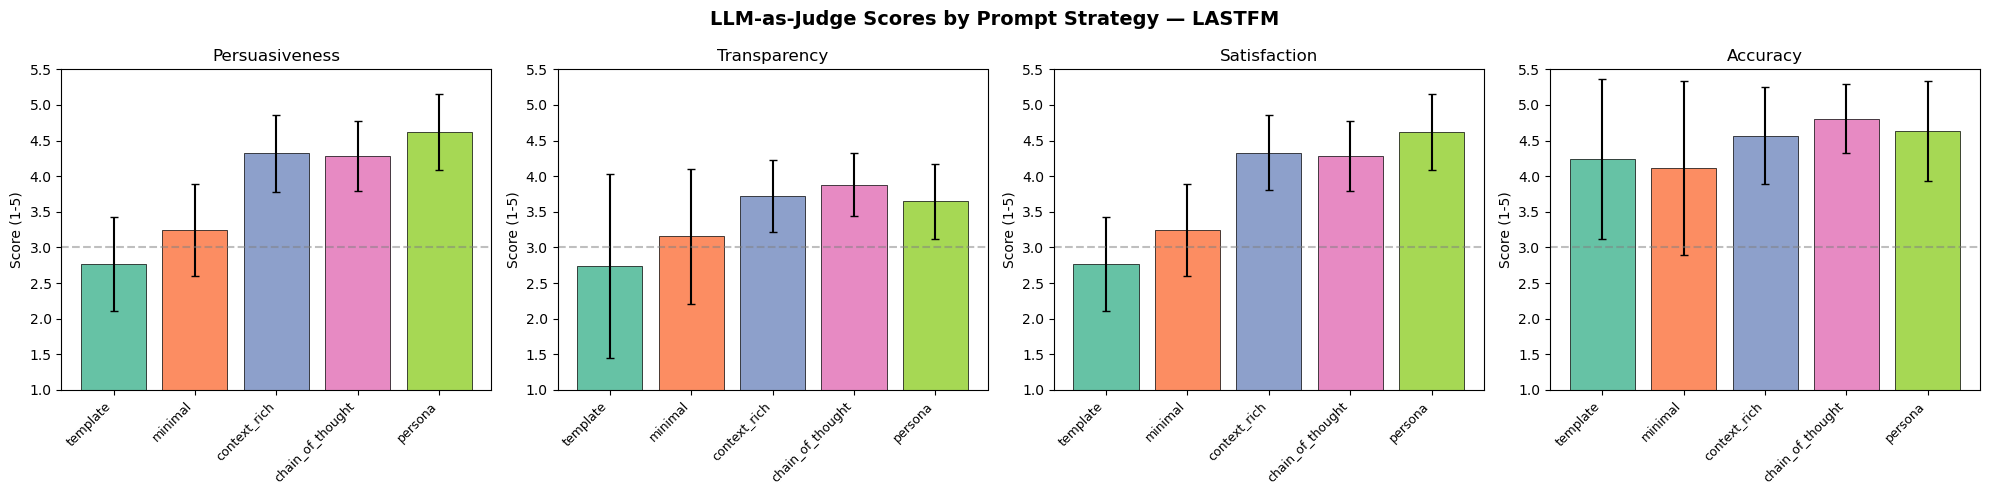

Saved: strategy_comparison_lastfm.png


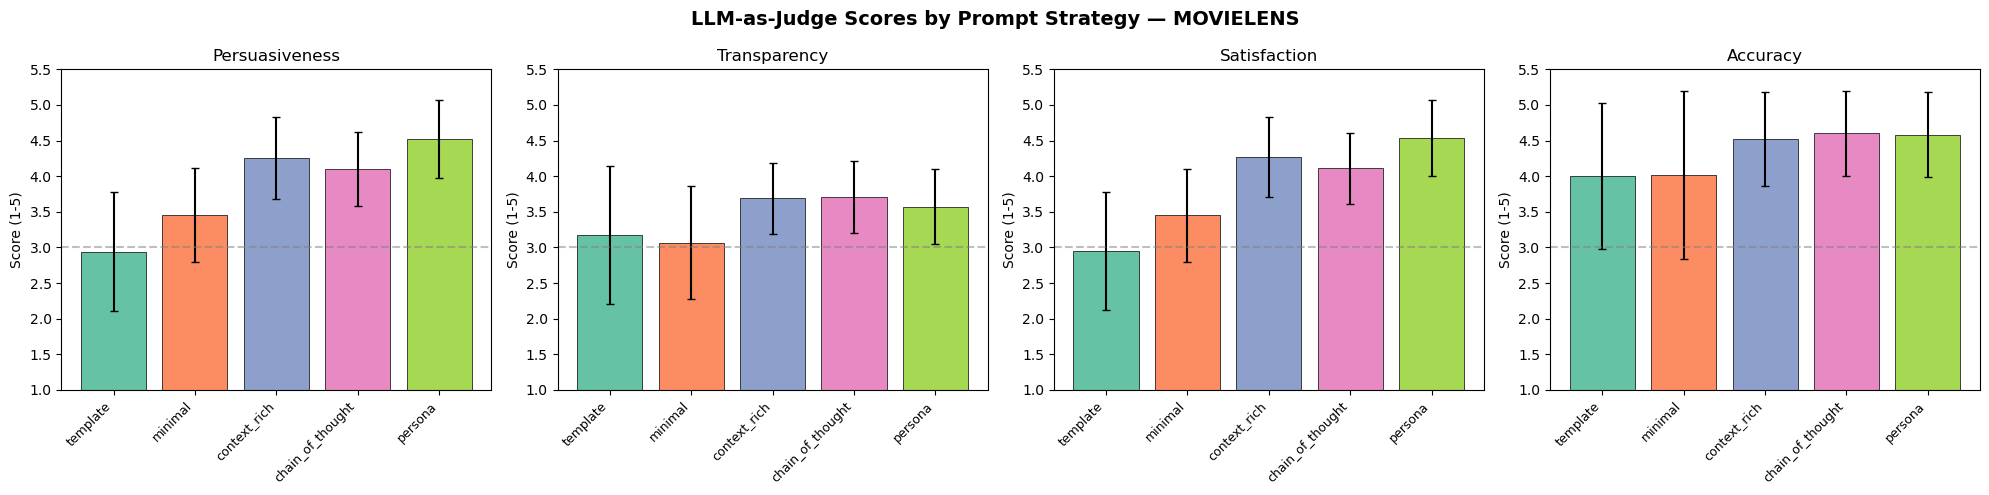

Saved: strategy_comparison_movielens.png


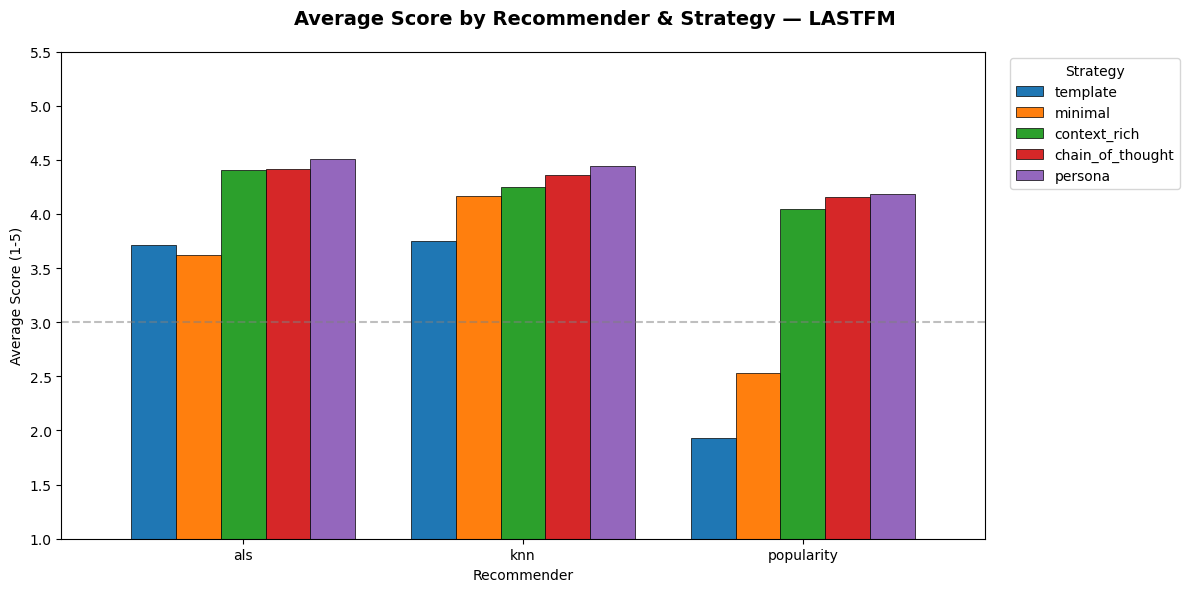

Saved: recommender_comparison_lastfm.png


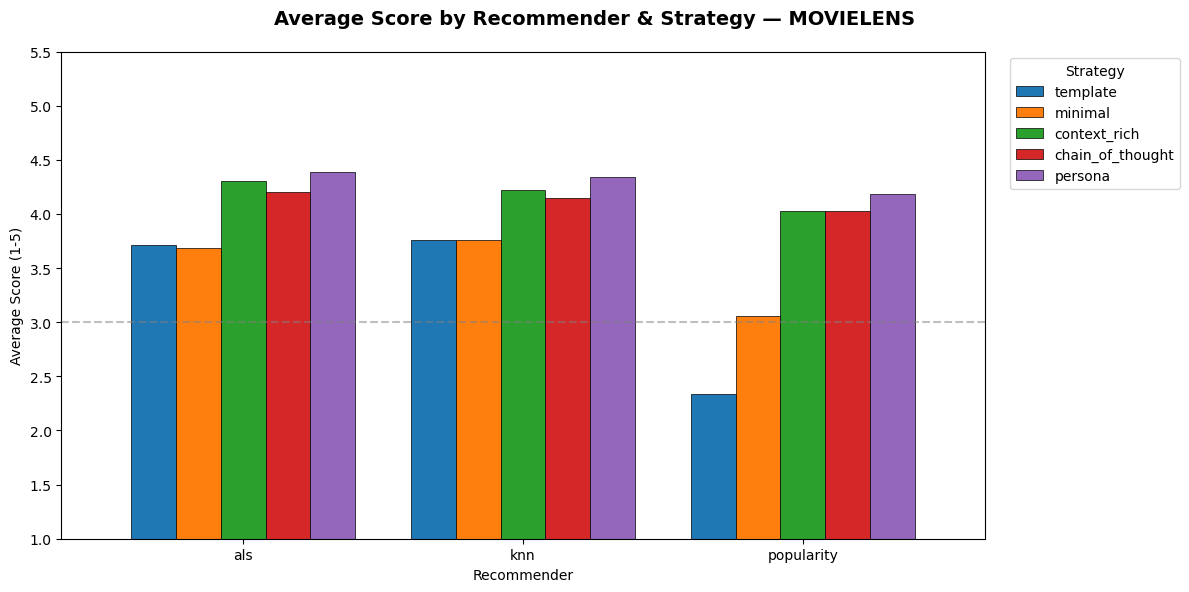

Saved: recommender_comparison_movielens.png


C:\Users\yung_dodik\AppData\Local\Temp\ipykernel_21852\229460759.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dfd, x='strategy', y=dim, order=strategy_order,
C:\Users\yung_dodik\AppData\Local\Temp\ipykernel_21852\229460759.py:79: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(strategy_order, rotation=45, ha='right', fontsize=9)
C:\Users\yung_dodik\AppData\Local\Temp\ipykernel_21852\229460759.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dfd, x='strategy', y=dim, order=strategy_order,
C:\Users\yung_dodik\AppData\Local\Temp\ipykernel_21852\229460759.py:79: UserWarnin

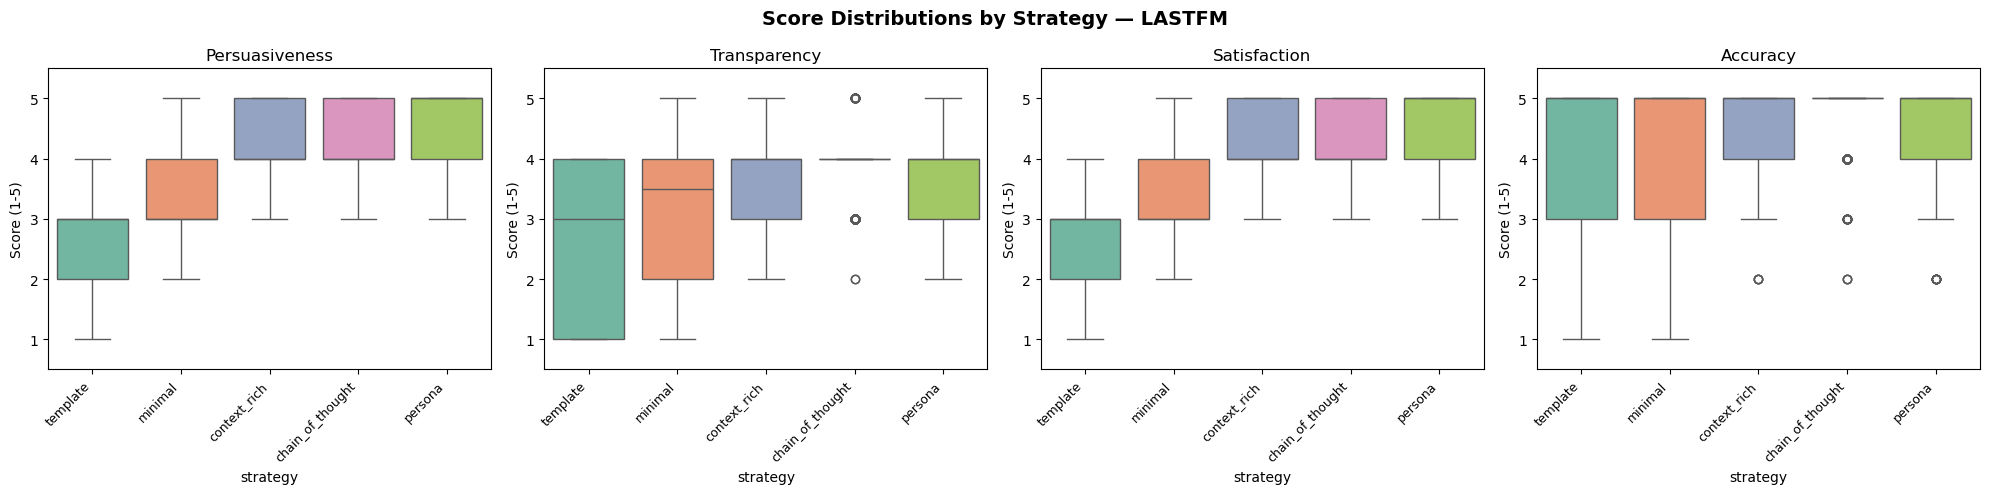

Saved: boxplots_lastfm.png


C:\Users\yung_dodik\AppData\Local\Temp\ipykernel_21852\229460759.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dfd, x='strategy', y=dim, order=strategy_order,
C:\Users\yung_dodik\AppData\Local\Temp\ipykernel_21852\229460759.py:79: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(strategy_order, rotation=45, ha='right', fontsize=9)
C:\Users\yung_dodik\AppData\Local\Temp\ipykernel_21852\229460759.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dfd, x='strategy', y=dim, order=strategy_order,
C:\Users\yung_dodik\AppData\Local\Temp\ipykernel_21852\229460759.py:79: UserWarnin

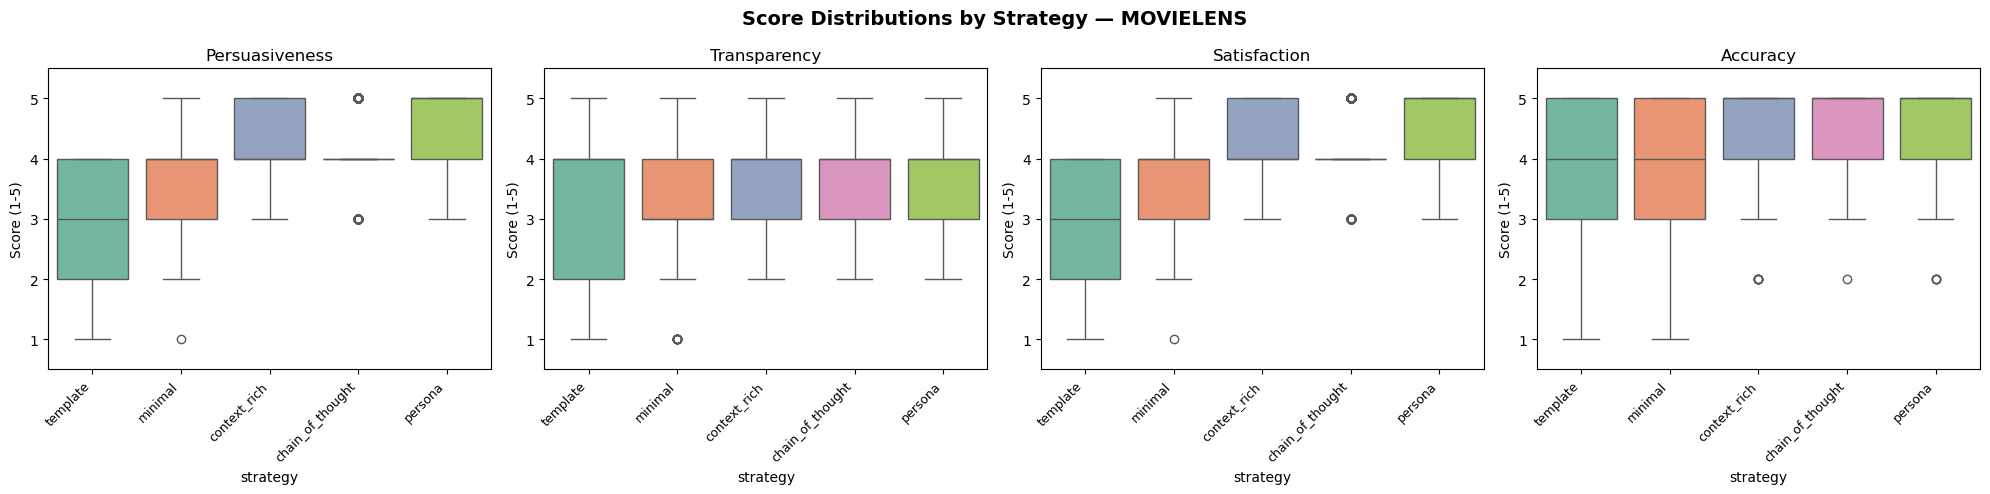

Saved: boxplots_movielens.png


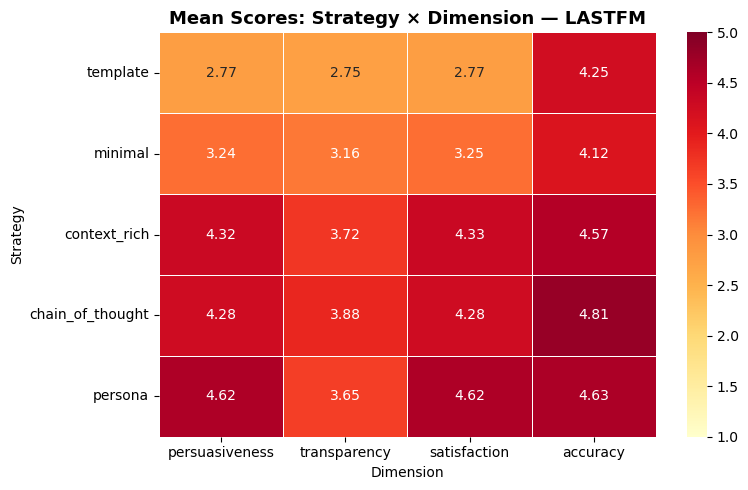

Saved: heatmap_lastfm.png


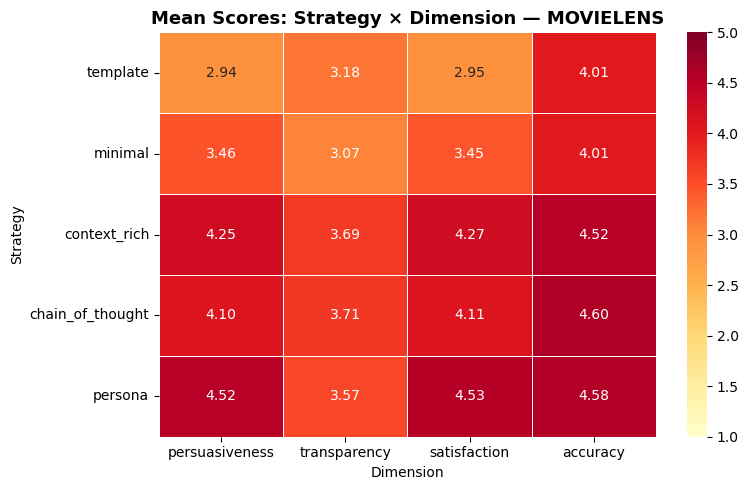

Saved: heatmap_movielens.png


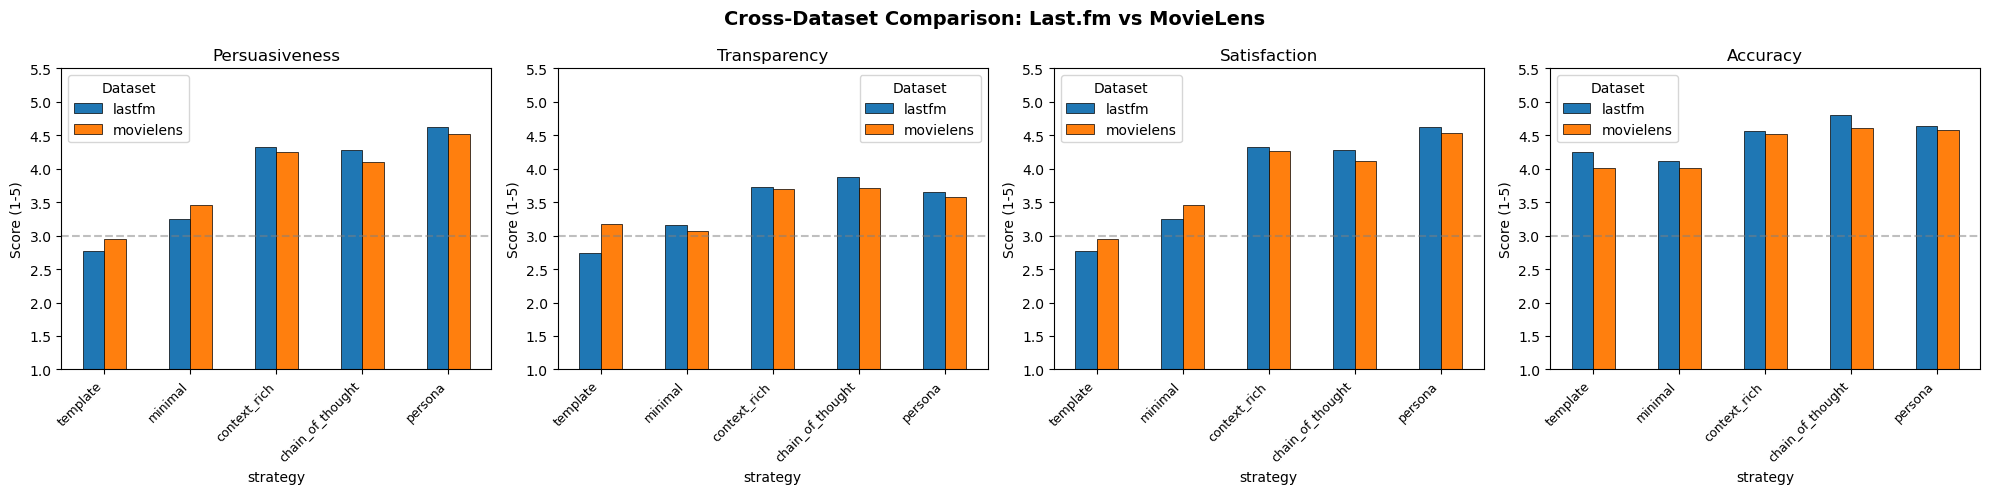

Saved: cross_dataset_comparison.png


In [60]:
plot_strategy_comparison(eval_df)
plot_recommender_comparison(eval_df)
plot_boxplots(eval_df)
plot_heatmap(eval_df)
plot_cross_dataset_comparison(eval_df)

In [61]:
sig_df = run_significance_tests(eval_df)

Significance tests

lastfm

movielens
Test results - lastfm
                  comparison      dimension  template_mean  strategy_mean    diff  p_value significant
         minimal vs template persuasiveness         2.7667         3.2440  0.4773   0.0000         ***
         minimal vs template   transparency         2.7453         3.1573  0.4120   0.0000         ***
         minimal vs template   satisfaction         2.7667         3.2453  0.4787   0.0000         ***
         minimal vs template       accuracy         4.2467         4.1173 -0.1293   0.0000         ***
         minimal vs template      avg_score         3.1313         3.4410  0.3097   0.0000         ***
    context_rich vs template persuasiveness         2.7667         4.3213  1.5547   0.0000         ***
    context_rich vs template   transparency         2.7453         3.7213  0.9760   0.0000         ***
    context_rich vs template   satisfaction         2.7667         4.3293  1.5627   0.0000         ***
    context_r

In [62]:
all_bertscore_dfs = []
 
for dataset in ['lastfm', 'movielens']:
    for recommender in ['knn', 'als', 'popularity']:
        exp_file = OUTPUT_DIR / f'explanations_{dataset}_{recommender}.json'
        if not exp_file.exists():
            # Try alternate path
            exp_file = Path(f'explanations_{dataset}_{recommender}.json')
        if exp_file.exists():
            df = compute_bertscore(exp_file, dataset, recommender)
            if len(df) > 0:
                all_bertscore_dfs.append(df)
        else:
            print(f"Not found: {exp_file}")
 
if all_bertscore_dfs:
    all_bertscore = pd.concat(all_bertscore_dfs, ignore_index=True)
    
    print(f"\n{'='*70}")
    print("BERTSCORE — Overall Summary (averaged across recommenders)")
    print(f"{'='*70}")
    for dataset in ['lastfm', 'movielens']:
        print(f"\n--- {dataset.upper()} ---")
        mask = all_bertscore['dataset'] == dataset
        summary = all_bertscore[mask].groupby('strategy')[['bertscore_precision', 'bertscore_recall', 'bertscore_f1']].mean()
        print(summary.round(4).to_string())
    
    # Save combined
    all_bertscore.to_csv(EVAL_DIR / 'bertscore_all.csv', index=False)
    print(f"\nCombined BERTScore: {len(all_bertscore)} rows")

c:\Users\yung_dodik\miniconda3\envs\recommender_env\lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\yung_dodik\.cache\huggingface\hub\models--roberta-large. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 389/389 [00:00<00:00, 9242.01it/s]
RobertaModel LOAD REPORT from:

calculating scores...
computing bert embedding.


100%|██████████| 40/40 [00:45<00:00,  1.13s/it]


computing greedy matching.


100%|██████████| 32/32 [00:00<00:00, 175.42it/s]


...

calculating scores...
computing bert embedding.


100%|██████████| 32/32 [00:39<00:00,  1.23s/it]


computing greedy matching.


100%|██████████| 32/32 [00:00<00:00, 200.68it/s]


done in 39.54 seconds, 25.29 sentences/sec

BERTSCORE — movielens / popularity
                  bertscore_precision  bertscore_recall  bertscore_f1
strategy                                                             
chain_of_thought               0.8569            0.8932        0.8746
context_rich                   0.8425            0.8821        0.8618
minimal                        0.8791            0.9076        0.8931
persona                        0.8381            0.8780        0.8576

Saved: evaluations\bertscore_movielens_popularity.csv (1000 rows)

BERTSCORE — Overall Summary (averaged across recommenders)

--- LASTFM ---
                  bertscore_precision  bertscore_recall  bertscore_f1
strategy                                                             
chain_of_thought               0.8664            0.8997        0.8826
context_rich                   0.8576            0.9018        0.8790
minimal                        0.8956            0.9088        0.9020
persona 

In [66]:
for fpath in sorted(glob.glob(str(OUTPUT_DIR / "explanations_*_llama31.json"))) + \
             sorted(glob.glob(str(OUTPUT_DIR / "explanations_*_gemma2.json"))):
    
    fpath = Path(fpath)
    fname = fpath.stem  # e.g. 'explanations_lastfm_knn_llama31'
    parts = fname.split('_')  # ['explanations', 'lastfm', 'knn', 'llama31']
    dataset = parts[1]
    recommender = parts[2]
    model_tag = parts[3]  # 'llama31' or 'gemma2'
    
    out_file = EVAL_DIR / f"eval_{dataset}_{recommender}_{model_tag}.json"
    print(f"\n{'='*60}")
    print(f"Evaluating: {fpath.name} → {out_file.name}")
    evaluate_all_explanations(fpath, output_file=out_file)


Evaluating: explanations_lastfm_als_llama31.json → eval_lastfm_als_llama31.json
Items: 250, Already done: 0
Strategies: ['template', 'minimal', 'context_rich', 'chain_of_thought', 'persona']


Evaluating:   4%|▍         | 10/250 [01:09<25:52,  6.47s/it]

  Saved: 10 evaluated


Evaluating:   8%|▊         | 20/250 [02:08<23:17,  6.08s/it]

  Saved: 20 evaluated


...

  Saved: 230 evaluated


Evaluating:  96%|█████████▌| 240/250 [24:01<00:57,  5.79s/it]

  Saved: 240 evaluated


Evaluating: 100%|██████████| 250/250 [25:01<00:00,  6.01s/it]

  Saved: 250 evaluated

250 items evaluated  saved to evaluations\eval_movielens_popularity_gemma2.json


In [67]:
for fpath in sorted(glob.glob(str(OUTPUT_DIR / "explanations_*_llama31.json"))) + \
             sorted(glob.glob(str(OUTPUT_DIR / "explanations_*_gemma2.json"))):
    compute_nlp_metrics(Path(fpath))

for fpath in sorted(glob.glob(str(OUTPUT_DIR / "explanations_*_llama31.json"))) + \
             sorted(glob.glob(str(OUTPUT_DIR / "explanations_*_gemma2.json"))):
    parts = Path(fpath).stem.split('_')
    compute_bertscore(Path(fpath), parts[1], parts[2])

NLP metrics saved: evaluations\nlp_metrics_lastfm_als.csv (1000 rows)
NLP METRICS — lastfm / als
                   bleu1   bleu2   bleu4  rouge1_f  rouge2_f  rougeL_f
strategy                                                              
chain_of_thought  0.3068  0.1802  0.0946    0.3308    0.1330    0.2128
context_rich      0.2033  0.1059  0.0446    0.2478    0.0894    0.1449
minimal           0.3041  0.1902  0.1162    0.3591    0.1388    0.2367
persona           0.2176  0.1203  0.0590    0.2504    0.0951    0.1661

NLP metrics saved: evaluations\nlp_metrics_lastfm_knn.csv (1000 rows)
NLP METRICS — lastfm / knn
                   bleu1   bleu2   bleu4  rouge1_f  rouge2_f  rougeL_f
strategy                                                              
chain_of_thought  0.2510  0.1585  0.0912    0.2924    0.1331    0.2210
context_rich      0.1647  0.0912  0.0413    0.2288    0.0936    0.1518
minimal           0.2343  0.1458  0.0887    0.2895    0.1077    0.2030
persona           0.1793

Loading weights: 100%|██████████| 389/389 [00:00<00:00, 10245.56it/s]
RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


calculating scores...
computing bert embedding.


100%|██████████| 39/39 [02:11<00:00,  3.37s/it]


computing greedy matching.


...

calculating scores...
computing bert embedding.


100%|██████████| 32/32 [00:37<00:00,  1.17s/it]


computing greedy matching.


100%|██████████| 32/32 [00:00<00:00, 139.04it/s]


done in 37.76 seconds, 26.48 sentences/sec

BERTSCORE — movielens / popularity
                  bertscore_precision  bertscore_recall  bertscore_f1
strategy                                                             
chain_of_thought               0.8613            0.8870        0.8739
context_rich                   0.8451            0.8797        0.8620
minimal                        0.8656            0.8878        0.8765
persona                        0.8391            0.8745        0.8564

Saved: evaluations\bertscore_movielens_popularity.csv (1000 rows)


In [ ]:
def load_all_eval_results(eval_dir=EVAL_DIR):
    rows = []
 
    for eval_file in sorted(eval_dir.glob("eval_*.json")):
        fname = eval_file.stem  # e.g. 'eval_lastfm_knn' or 'eval_lastfm_knn_llama31'
        parts = fname.split('_')
 
        # Determine model from filename
        if len(parts) == 3:  # eval_lastfm_knn → GPT
            model = 'gpt-4.1-mini'
        elif len(parts) == 4:  # eval_lastfm_knn_llama31
            tag = parts[3]
            if 'llama' in tag:
                model = 'llama-3.1-8b'
            elif 'gemma' in tag:
                model = 'gemma-2-9b'
            else:
                model = tag
        else:
            continue
 
        with open(eval_file, 'r') as f:
            data = json.load(f)
 
        for item in data:
            for strategy, scores in item['scores'].items():
                if scores.get('persuasiveness') is None:
                    continue
 
                row = {
                    'dataset': item['dataset'],
                    'recommender': item['recommender'],
                    'user_id': item['user_id'],
                    'strategy': strategy,
                    'model': model,
                    'persuasiveness': scores['persuasiveness'],
                    'transparency': scores['transparency'],
                    'satisfaction': scores['satisfaction'],
                    'accuracy': scores['accuracy'],
                }
                row['avg_score'] = np.mean([
                    scores['persuasiveness'],
                    scores['transparency'],
                    scores['satisfaction'],
                    scores['accuracy']
                ])
                rows.append(row)
 
    df = pd.DataFrame(rows)
    print(f"Loaded {len(df)} records across {df['model'].nunique()} models")
    print(f"Models: {sorted(df['model'].unique())}")
    return df
 
all_eval_df = load_all_eval_results()

Loaded 22500 records across 3 models
Models: ['gemma-2-9b', 'gpt-4.1-mini', 'llama-3.1-8b']


In [ ]:
def print_model_comparison(df):
    dimensions = ['persuasiveness', 'transparency', 'satisfaction', 'accuracy', 'avg_score']
 
    for dataset in sorted(df['dataset'].unique()):
        print(f"\n{'='*80}")
        print(f"  {dataset.upper()}")
        print(f"{'='*80}")
 
        dfd = df[df['dataset'] == dataset]
 
        for model in sorted(dfd['model'].unique()):
            print(f"\n  Model: {model}")
            print(f"  {'Strategy':<20s} {'Pers':>7s} {'Trans':>7s} {'Sat':>7s} {'Acc':>7s} {'Avg':>7s}")
            print(f"  {'-'*55}")
 
            dfm = dfd[dfd['model'] == model]
            for strategy in ['template', 'minimal', 'context_rich', 'chain_of_thought', 'persona']:
                dfs = dfm[dfm['strategy'] == strategy]
                if len(dfs) == 0:
                    continue
                vals = [dfs[d].mean() for d in dimensions]
                print(f"  {strategy:<20s} {vals[0]:7.2f} {vals[1]:7.2f} {vals[2]:7.2f} {vals[3]:7.2f} {vals[4]:7.2f}")
 
print_model_comparison(all_eval_df)


  LASTFM

  Model: gemma-2-9b
  Strategy                Pers   Trans     Sat     Acc     Avg
  -------------------------------------------------------
  template                2.76    2.74    2.76    4.27    3.13
  minimal                 3.36    2.82    3.37    4.10    3.41
  context_rich            3.84    3.37    3.83    3.96    3.75
  chain_of_thought        4.05    3.70    4.06    4.67    4.12
  persona                 4.16    3.16    4.16    4.40    3.97

  Model: gpt-4.1-mini
  Strategy                Pers   Trans     Sat     Acc     Avg
  -------------------------------------------------------
  template                2.77    2.75    2.77    4.25    3.13
  minimal                 3.24    3.16    3.25    4.12    3.44
  context_rich            4.32    3.72    4.33    4.57    4.24
  chain_of_thought        4.28    3.88    4.28    4.81    4.31
  persona                 4.62    3.65    4.62    4.63    4.38

  Model: llama-3.1-8b
  Strategy                Pers   Trans     Sat     

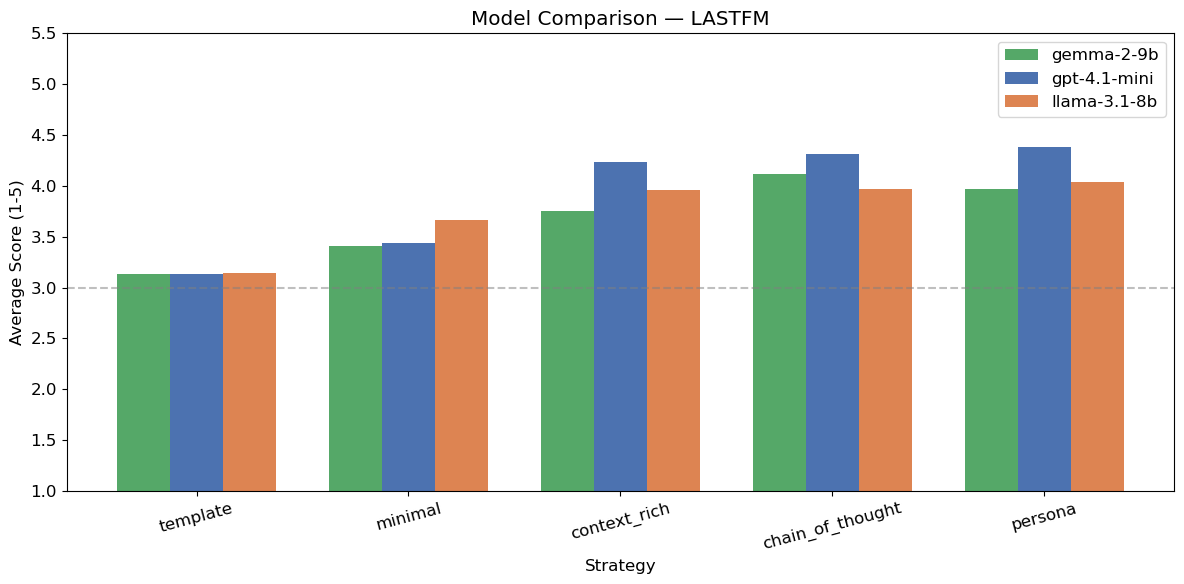

Saved: evaluations\model_comparison_lastfm.png


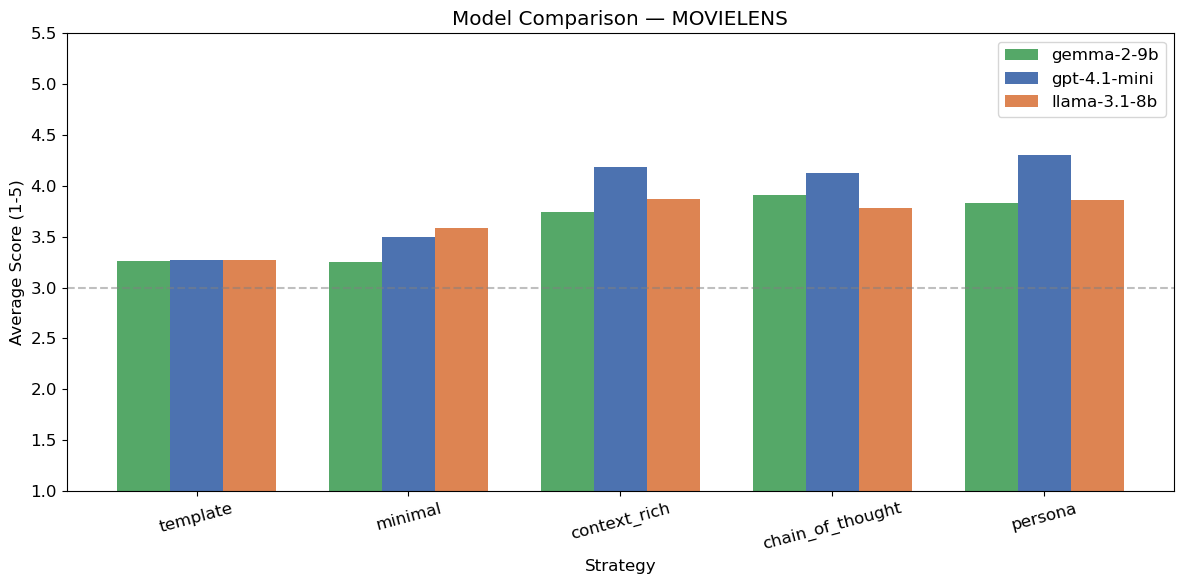

Saved: evaluations\model_comparison_movielens.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 12})
 
def plot_model_comparison(df, save_dir=EVAL_DIR):
 
    strategies = ['template', 'minimal', 'context_rich', 'chain_of_thought', 'persona']
    models = sorted(df['model'].unique())
    colors = {'gpt-4.1-mini': '#4C72B0', 'llama-3.1-8b': '#DD8452', 'gemma-2-9b': '#55A868'}
 
    for dataset in sorted(df['dataset'].unique()):
        dfd = df[df['dataset'] == dataset]
 
        fig, ax = plt.subplots(figsize=(12, 6))
 
        x = np.arange(len(strategies))
        width = 0.25
        offsets = np.linspace(-width, width, len(models))
 
        for j, model in enumerate(models):
            dfm = dfd[dfd['model'] == model]
            means = [dfm[dfm['strategy'] == s]['avg_score'].mean() for s in strategies]
            color = colors.get(model, f'C{j}')
            ax.bar(x + offsets[j], means, width, label=model, color=color)
 
        ax.set_xlabel('Strategy')
        ax.set_ylabel('Average Score (1-5)')
        ax.set_title(f'Model Comparison — {dataset.upper()}')
        ax.set_xticks(x)
        ax.set_xticklabels(strategies, rotation=15)
        ax.legend()
        ax.set_ylim(1, 5.5)
        ax.axhline(y=3, color='gray', linestyle='--', alpha=0.5)
 
        plt.tight_layout()
        out = save_dir / f'model_comparison_{dataset}.png'
        fig.savefig(out, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"Saved: {out}")
 
plot_model_comparison(all_eval_df)

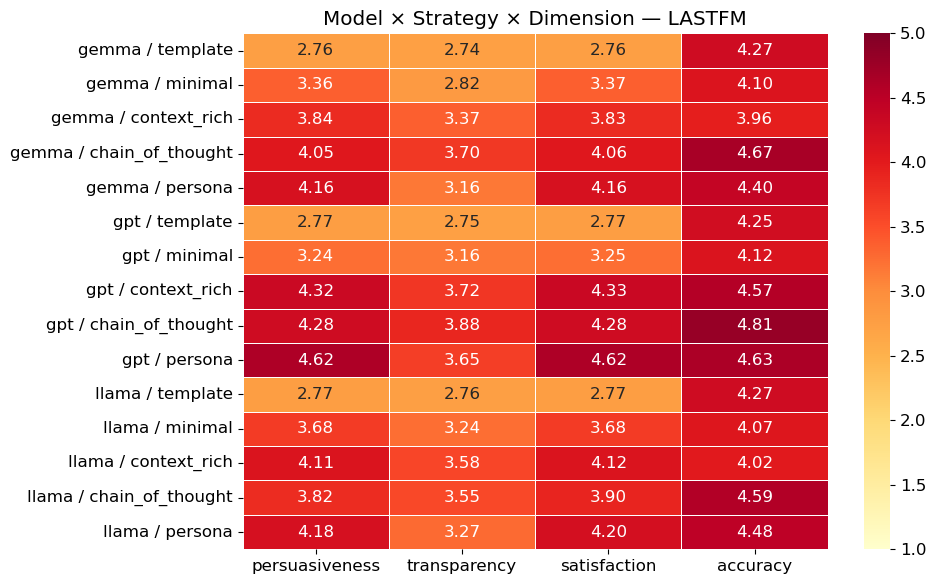

Saved: evaluations\model_heatmap_lastfm.png


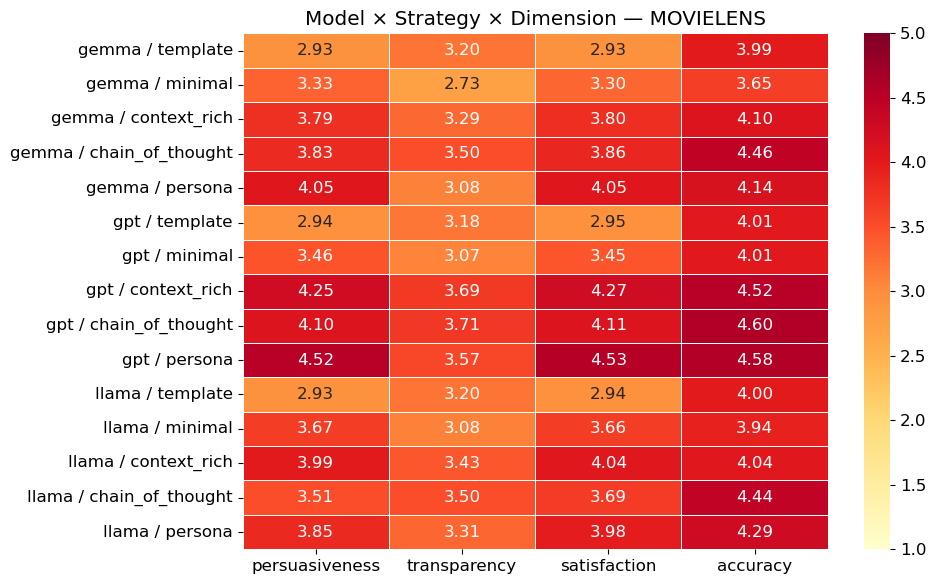

Saved: evaluations\model_heatmap_movielens.png


In [ ]:
def plot_model_dimension_heatmap(df, save_dir=EVAL_DIR):
    import seaborn as sns
 
    dimensions = ['persuasiveness', 'transparency', 'satisfaction', 'accuracy']
    strategies = ['template', 'minimal', 'context_rich', 'chain_of_thought', 'persona']
    models = sorted(df['model'].unique())
 
    for dataset in sorted(df['dataset'].unique()):
        dfd = df[df['dataset'] == dataset]
 
        row_labels = []
        heat_data = []
 
        for model in models:
            for strategy in strategies:
                dfs = dfd[(dfd['model'] == model) & (dfd['strategy'] == strategy)]
                if len(dfs) == 0:
                    continue
                vals = [dfs[d].mean() for d in dimensions]
                heat_data.append(vals)
                short_model = model.split('-')[0] if '-' in model else model
                row_labels.append(f"{short_model} / {strategy}")
 
        heat_df = pd.DataFrame(heat_data, index=row_labels, columns=dimensions)
 
        fig, ax = plt.subplots(figsize=(10, max(6, len(row_labels) * 0.4)))
        sns.heatmap(heat_df, annot=True, fmt='.2f', cmap='YlOrRd',
                    vmin=1, vmax=5, ax=ax, linewidths=0.5)
        ax.set_title(f'Model × Strategy × Dimension — {dataset.upper()}')
 
        plt.tight_layout()
        out = save_dir / f'model_heatmap_{dataset}.png'
        fig.savefig(out, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"Saved: {out}")
 
plot_model_dimension_heatmap(all_eval_df)

In [ ]:
from scipy import stats
 
def test_models_vs_gpt(df):
    dimensions = ['persuasiveness', 'transparency', 'satisfaction', 'accuracy', 'avg_score']
    results = []
 
    for dataset in sorted(df['dataset'].unique()):
        dfd = df[df['dataset'] == dataset]
        gpt_df = dfd[dfd['model'] == 'gpt-4.1-mini']
 
        for model in sorted(dfd['model'].unique()):
            if model == 'gpt-4.1-mini':
                continue
 
            model_df = dfd[dfd['model'] == model]
 
            for strategy in ['minimal', 'context_rich', 'chain_of_thought', 'persona']:
                for dim in dimensions:
                    gpt_vals = gpt_df[gpt_df['strategy'] == strategy][dim].values
                    mod_vals = model_df[model_df['strategy'] == strategy][dim].values
 
                    n = min(len(gpt_vals), len(mod_vals))
                    if n < 5:
                        continue
 
                    try:
                        stat, p_value = stats.wilcoxon(gpt_vals[:n], mod_vals[:n])
                        sig = '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else ''
 
                        results.append({
                            'dataset': dataset,
                            'comparison': f'{model} vs gpt-4.1-mini',
                            'strategy': strategy,
                            'dimension': dim,
                            'gpt_mean': np.mean(gpt_vals[:n]),
                            'model_mean': np.mean(mod_vals[:n]),
                            'diff': np.mean(mod_vals[:n]) - np.mean(gpt_vals[:n]),
                            'p_value': p_value,
                            'significant': sig,
                        })
                    except Exception:
                        pass
 
    results_df = pd.DataFrame(results)
 
    if len(results_df) > 0:
        print(f"\n{'='*80}")
        print("MODEL vs GPT — Average Score Comparison")
        print(f"{'='*80}")
 
        for dataset in sorted(results_df['dataset'].unique()):
            print(f"\n--- {dataset.upper()} ---")
            mask = (results_df['dataset'] == dataset) & (results_df['dimension'] == 'avg_score')
            display = results_df[mask][['comparison', 'strategy', 'gpt_mean', 'model_mean', 'diff', 'p_value', 'significant']]
            print(display.round(4).to_string(index=False))
 
        results_df.to_csv(EVAL_DIR / 'model_comparison_tests.csv', index=False)
        print(f"\nSaved: model_comparison_tests.csv")
 
    return results_df
 
model_test_df = test_models_vs_gpt(all_eval_df)


MODEL vs GPT — Average Score Comparison

--- LASTFM ---
                  comparison         strategy  gpt_mean  model_mean    diff  p_value significant
  gemma-2-9b vs gpt-4.1-mini          minimal    3.4410      3.4123 -0.0287   0.4135            
  gemma-2-9b vs gpt-4.1-mini     context_rich    4.2357      3.7500 -0.4857   0.0000         ***
  gemma-2-9b vs gpt-4.1-mini chain_of_thought    4.3110      4.1190 -0.1920   0.0000         ***
  gemma-2-9b vs gpt-4.1-mini          persona    4.3793      3.9690 -0.4103   0.0000         ***
llama-3.1-8b vs gpt-4.1-mini          minimal    3.4410      3.6683  0.2273   0.0000         ***
llama-3.1-8b vs gpt-4.1-mini     context_rich    4.2357      3.9593 -0.2763   0.0000         ***
llama-3.1-8b vs gpt-4.1-mini chain_of_thought    4.3110      3.9667 -0.3443   0.0000         ***
llama-3.1-8b vs gpt-4.1-mini          persona    4.3793      4.0347 -0.3447   0.0000         ***

--- MOVIELENS ---
                  comparison         strategy  gpt_

In [1]:
import json
import glob
import numpy as np
import pandas as pd
from pathlib import Path
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
from bert_score import score as bert_score
 
OUTPUT_DIR = Path('explanations')
EVAL_DIR = Path('evaluations')
 
smoother = SmoothingFunction().method1
rouge = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

def load_explanations(filepath):
    with open(filepath, 'r') as f:
        data = json.load(f)
    
    result = {}
    for item in data:
        # Build a unique key per user-item pair
        if 'track' in item:
            item_key = (item['user_id'], item['track'])
        else:
            item_key = (item['user_id'], item['title'])
        
        explanations = {}
        for strategy, exp_data in item.get('llm_explanations', {}).items():
            explanations[strategy] = exp_data.get('explanation', '')
        
        result[item_key] = explanations
    
    return result
 
 
def compute_pairwise_metrics(exps_a, exps_b, model_a_name, model_b_name, dataset, recommender):
    
    strategies = ['minimal', 'context_rich', 'chain_of_thought', 'persona']
    rows = []
    
    # Collect paired texts for BERTScore (batch computation)
    bert_candidates = []
    bert_references = []
    bert_meta = []
    
    common_keys = set(exps_a.keys()) & set(exps_b.keys())
    
    for key in common_keys:
        for strategy in strategies:
            text_a = exps_a[key].get(strategy, '')
            text_b = exps_b[key].get(strategy, '')
            
            if not text_a or not text_b:
                continue
            
            ref_tokens = text_b.split()
            cand_tokens = text_a.split()
            
            bleu1 = sentence_bleu([ref_tokens], cand_tokens, weights=(1, 0, 0, 0), smoothing_function=smoother)
            bleu4 = sentence_bleu([ref_tokens], cand_tokens, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoother)
            
            r_scores = rouge.score(text_b, text_a)
            
            rows.append({
                'dataset': dataset,
                'recommender': recommender,
                'comparison': f'{model_a_name} vs {model_b_name}',
                'strategy': strategy,
                'user_item': f'{key[0]}_{key[1][:30]}',
                'bleu1': bleu1,
                'bleu4': bleu4,
                'rouge1_f': r_scores['rouge1'].fmeasure,
                'rouge2_f': r_scores['rouge2'].fmeasure,
                'rougeL_f': r_scores['rougeL'].fmeasure,
            })
            
            bert_candidates.append(text_a)
            bert_references.append(text_b)
            bert_meta.append(len(rows) - 1)
    
    if bert_candidates:
        P, R, F1 = bert_score(bert_candidates, bert_references, lang='en', verbose=True, batch_size=32)
        for i, row_idx in enumerate(bert_meta):
            rows[row_idx]['bertscore_f1'] = F1[i].item()
    
    return pd.DataFrame(rows)

model_tags = {
    'gpt': '',
    'llama': '_llama31',
    'gemma': '_gemma2',
}
 
comparisons = [
    ('gpt', 'llama'),
    ('gpt', 'gemma'),
    ('llama', 'gemma'),
]
 
all_results = []
 
for dataset in ['lastfm', 'movielens']:
    for recommender in ['knn', 'als', 'popularity']:
        # Load all three models' explanations
        model_exps = {}
        for model_name, suffix in model_tags.items():
            filepath = OUTPUT_DIR / f'explanations_{dataset}_{recommender}{suffix}.json'
            if filepath.exists():
                model_exps[model_name] = load_explanations(filepath)
                print(f"Loaded: {filepath.name} ({len(model_exps[model_name])} items)")
            else:
                print(f"Not found: {filepath}")
        
        for model_a, model_b in comparisons:
            if model_a not in model_exps or model_b not in model_exps:
                print(f"  Skipping {model_a} vs {model_b} for {dataset}/{recommender} (missing data)")
                continue
            
            print(f"\n  Computing: {model_a} vs {model_b} — {dataset}/{recommender}")
            df = compute_pairwise_metrics(
                model_exps[model_a], model_exps[model_b],
                model_a, model_b, dataset, recommender
            )
            all_results.append(df)
 
if all_results:
    cross_model_df = pd.concat(all_results, ignore_index=True)
    
    metrics = ['bleu1', 'bleu4', 'rouge1_f', 'rougeL_f', 'bertscore_f1']
    
    print(f"\n{'='*80}")
    print("CROSS-MODEL SIMILARITY — Averaged across recommenders")
    print(f"{'='*80}")
    
    for dataset in ['lastfm', 'movielens']:
        print(f"\n--- {dataset.upper()} ---")
        mask = cross_model_df['dataset'] == dataset
        
        for comparison in ['gpt vs llama', 'gpt vs gemma', 'llama vs gemma']:
            cmask = mask & (cross_model_df['comparison'] == comparison)
            if cmask.sum() == 0:
                continue
            
            print(f"\n  {comparison}:")
            summary = cross_model_df[cmask].groupby('strategy')[metrics].mean()
            print(summary.round(4).to_string())
    
    out_path = EVAL_DIR / 'cross_model_nlp_metrics.csv'
    cross_model_df.to_csv(out_path, index=False)
    print(f"\nSaved: {out_path} ({len(cross_model_df)} rows)")
    
    print(f"\n{'='*80}")
    print("OVERALL CROSS-MODEL SIMILARITY (all strategies averaged)")
    print(f"{'='*80}")
    
    overall = cross_model_df.groupby(['dataset', 'comparison'])[metrics].mean()
    print(overall.round(4).to_string())

c:\Users\yung_dodik\miniconda3\envs\recommender_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded: explanations_lastfm_knn.json (250 items)
Loaded: explanations_lastfm_knn_llama31.json (250 items)
Loaded: explanations_lastfm_knn_gemma2.json (250 items)

  Computing: gpt vs llama — lastfm/knn


Loading weights: 100%|██████████| 389/389 [00:00<00:00, 6250.42it/s]
RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


calculating scores...
computing bert embedding.


100%|██████████| 63/63 [01:42<00:00,  1.63s/it]


...

calculating scores...
computing bert embedding.


100%|██████████| 63/63 [01:25<00:00,  1.35s/it]


computing greedy matching.


100%|██████████| 32/32 [00:00<00:00, 110.50it/s]


done in 85.57 seconds, 11.69 sentences/sec

CROSS-MODEL SIMILARITY — Averaged across recommenders

--- LASTFM ---

  gpt vs llama:
                   bleu1   bleu4  rouge1_f  rougeL_f  bertscore_f1
strategy                                                          
chain_of_thought  0.2833  0.0586    0.4126    0.2310        0.8928
context_rich      0.2593  0.0362    0.4115    0.2109        0.8782
minimal           0.2617  0.0613    0.4140    0.2463        0.8965
persona           0.2720  0.0404    0.4040    0.2046        0.8759

  gpt vs gemma:
                   bleu1   bleu4  rouge1_f  rougeL_f  bertscore_f1
strategy                                                          
chain_of_thought  0.3249  0.0745    0.4542    0.2415        0.9024
context_rich      0.3012  0.0704    0.4428    0.2660        0.8924
minimal           0.2820  0.0851    0.4011    0.2554        0.8953
persona           0.2660  0.0533    0.3911    0.2135        0.8808

  llama vs gemma:
                   bleu1   bl

In [73]:
import glob
for exp_file in sorted(glob.glob(str(OUTPUT_DIR / "explanations_*.json"))):
    rec_name = Path(exp_file).stem.split('_')[-1]
    dataset_name = Path(exp_file).stem.split('_')[-2]
    eval_file = EVAL_DIR / f"eval_{dataset_name}_{rec_name}.json"
    if eval_file.exists():
        show_qualitative_examples(exp_file, eval_file, n=3)


Examples: explanations_lastfm_als.json

Item: "When The Levee Breaks" by Dread Zeppelin
Best strategy: chain_of_thought (avg=4.0)
Worst strategy: minimal (avg=3.0)

[chain_of_thought]: Given your affinity for classic rock legends like Led Zeppelin, AC/DC, and Pearl Jam, "When The Levee Breaks" by Dread Zeppelin is a great fit, as it captures the heavy blues-rock energy and iconic sound you enjoy. This track aligns with your tastes for powerful, guitar-driven music with a classic f

[minimal]: This track was recommended because your listening preferences align closely with the underlying musical features captured by the recommendation model. "When The Levee Breaks" by Dread Zeppelin shares key latent characteristics with other tracks you enjoy, making it a great match for your unique tast


Item: "Ramble On" by Dread Zeppelin
Best strategy: context_rich (avg=4.0)
Worst strategy: minimal (avg=3.0)

[context_rich]: Hey! Since you enjoy classic and hard rock bands like Led Zeppelin, Pearl